# Participant Log Analysis

This notebook analyzes the participant log summary data from the research study comparing Baseline tools vs Novel System (NS) conditions.

In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

In [22]:
# Load the participant log summary data
df = pd.read_csv('participants_log_summary.csv')

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
df.head()

Data loaded successfully!
Shape: (40, 13)
Columns: ['participant_id', 'condition', 'final_time', 'insights_generated', 'factors_explored', 'factors_included_in_story', 'factors_used_in_decision', 'branches_created', 'divergence_semantic_distance_avg', 'divergence_semantic_distance_min', 'divergence_semantic_distance_max', 'reflection_events', 'reflection_edit_coupled']

First few rows:


,participant_id,condition,final_time,insights_generated,factors_explored,factors_included_in_story,factors_used_in_decision,branches_created,divergence_semantic_distance_avg,divergence_semantic_distance_min,divergence_semantic_distance_max,reflection_events,reflection_edit_coupled
0,597fe89a1b41a20001749f57,Baseline,29.45,7,5,NaN,2,3,NaN,NaN,NaN,4,3
1,597fe89a1b41a20001749f57,NS,31.12,10,7,NaN,4,7,NaN,NaN,NaN,11,0
2,5f4520ebb012170878012efc,Baseline,30.89,7,4,NaN,3,8,NaN,NaN,NaN,4,4
3,5f4520ebb012170878012efc,NS,32.34,11,6,NaN,3,6,NaN,NaN,NaN,13,3
4,607668ac450fc6e3025a131d,Baseline,28.77,7,5,NaN,2,4,NaN,NaN,NaN,4,2


In [23]:
# Display basic information about the dataset
print("=== Dataset Overview ===")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Unique participants: {df['participant_id'].nunique()}")
print(f"Conditions: {df['condition'].unique()}")

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
missing_vals = df.isnull().sum()
if missing_vals.sum() > 0:
    print(missing_vals[missing_vals > 0])
else:
    print("No missing values found.")

print("\n=== Summary Statistics ===")
df.describe()

=== Dataset Overview ===
Total rows: 40
Total columns: 13
Unique participants: 20
Conditions: ['Baseline' 'NS']

=== Data Types ===
participant_id                       object
condition                            object
final_time                          float64
insights_generated                    int64
factors_explored                      int64
factors_included_in_story           float64
factors_used_in_decision              int64
branches_created                      int64
divergence_semantic_distance_avg    float64
divergence_semantic_distance_min    float64
divergence_semantic_distance_max    float64
reflection_events                     int64
reflection_edit_coupled               int64
dtype: object

=== Missing Values ===
factors_included_in_story           40
divergence_semantic_distance_avg    40
divergence_semantic_distance_min    40
divergence_semantic_distance_max    40
dtype: int64

=== Summary Statistics ===


,final_time,insights_generated,factors_explored,factors_included_in_story,factors_used_in_decision,branches_created,divergence_semantic_distance_avg,divergence_semantic_distance_min,divergence_semantic_distance_max,reflection_events,reflection_edit_coupled
count,40.000000,40.000000,40.000000,0.0,40.000000,40.000000,0.0,0.0,0.0,40.000000,40.00000
mean,30.713000,11.050000,6.150000,NaN,3.125000,5.750000,NaN,NaN,NaN,10.650000,2.47500
std,1.252252,6.744228,1.442043,NaN,0.938835,4.174096,NaN,NaN,NaN,5.106808,1.97403
min,28.650000,4.000000,3.000000,NaN,1.000000,0.000000,NaN,NaN,NaN,3.000000,0.00000
25%,29.647500,6.750000,5.000000,NaN,2.750000,3.000000,NaN,NaN,NaN,6.750000,0.00000
50%,30.690000,9.500000,6.000000,NaN,3.000000,6.000000,NaN,NaN,NaN,10.500000,3.00000
75%,31.502500,12.250000,7.000000,NaN,4.000000,8.000000,NaN,NaN,NaN,14.250000,4.00000
max,33.210000,35.000000,8.000000,NaN,5.000000,18.000000,NaN,NaN,NaN,25.000000,6.00000


## Alternative Explored Events Timeline Analysis

Analyzing the temporal distribution of "alternative_explored" events across all participants, comparing Baseline vs Novel System conditions.

In [24]:
# Collect all alternative_explored events from participant event logs
import os
import glob

def collect_alternative_explored_events():
    """
    Collect all alternative_explored events from participant event files
    Returns: dict with 'baseline' and 'ns' lists of timestamps
    """
    
    baseline_events = []
    ns_events = []
    
    # Get all participant event files
    event_folder = 'participant_events'
    baseline_files = glob.glob(f'{event_folder}/*_baseline.csv')
    ns_files = glob.glob(f'{event_folder}/*_ns.csv')
    
    print(f"Found {len(baseline_files)} baseline files and {len(ns_files)} NS files")
    
    # Process baseline files
    for file_path in baseline_files:
        try:
            events_df = pd.read_csv(file_path)
            alternative_events = events_df[events_df['event_type'] == 'alternative_explored']
            baseline_events.extend(alternative_events['timestamp_normalized'].tolist())
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    # Process NS files
    for file_path in ns_files:
        try:
            events_df = pd.read_csv(file_path)
            alternative_events = events_df[events_df['event_type'] == 'alternative_explored']
            ns_events.extend(alternative_events['timestamp_normalized'].tolist())
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    return {
        'baseline': baseline_events,
        'ns': ns_events
    }

# Collect the events
alternative_events = collect_alternative_explored_events()

print(f"Baseline alternative_explored events: {len(alternative_events['baseline'])}")
print(f"NS alternative_explored events: {len(alternative_events['ns'])}")

if alternative_events['baseline']:
    print(f"Baseline range: {min(alternative_events['baseline']):.3f} - {max(alternative_events['baseline']):.3f}")
if alternative_events['ns']:
    print(f"NS range: {min(alternative_events['ns']):.3f} - {max(alternative_events['ns']):.3f}")

Found 20 baseline files and 20 NS files
Baseline alternative_explored events: 65
NS alternative_explored events: 175
Baseline range: 0.128 - 0.925
NS range: 0.027 - 0.979


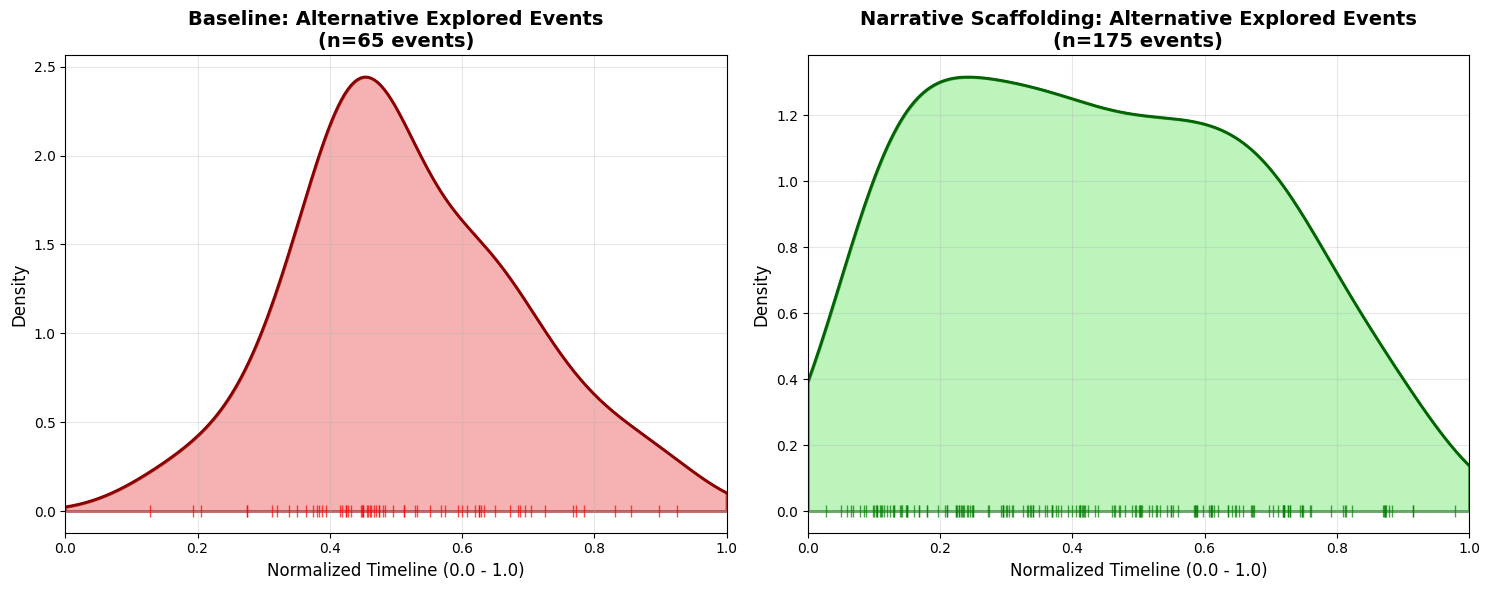


=== Summary Statistics ===
Baseline - Mean: 0.517, Std: 0.168, Median: 0.475
NS - Mean: 0.438, Std: 0.240, Median: 0.416


In [25]:
# Create continuous density plots for alternative_explored events using KDE
from scipy.stats import gaussian_kde

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Baseline density plot
if alternative_events['baseline'] and len(alternative_events['baseline']) > 1:
    # Create KDE
    kde_baseline = gaussian_kde(alternative_events['baseline'])
    x_baseline = np.linspace(0, 1, 200)
    density_baseline = kde_baseline(x_baseline)
    
    # Plot continuous density
    ax1.fill_between(x_baseline, density_baseline, alpha=0.6, color='lightcoral', 
                     edgecolor='darkred', linewidth=2)
    ax1.plot(x_baseline, density_baseline, color='darkred', linewidth=2)
    
    # Add rug plot for actual data points
    ax1.plot(alternative_events['baseline'], np.zeros_like(alternative_events['baseline']), 
             '|', color='red', markersize=8, alpha=0.7)
    
    ax1.set_title(f'Baseline: Alternative Explored Events\n(n={len(alternative_events["baseline"])} events)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
elif alternative_events['baseline'] and len(alternative_events['baseline']) == 1:
    # Single point - show as vertical line
    ax1.axvline(alternative_events['baseline'][0], color='red', linewidth=3, alpha=0.8)
    ax1.set_title(f'Baseline: Alternative Explored Events\n(n=1 event)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
else:
    ax1.text(0.5, 0.5, 'No alternative_explored\nevents in baseline', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Baseline: Alternative Explored Events', fontsize=14, fontweight='bold')

# NS density plot  
if alternative_events['ns'] and len(alternative_events['ns']) > 1:
    # Create KDE
    kde_ns = gaussian_kde(alternative_events['ns'])
    x_ns = np.linspace(0, 1, 200)
    density_ns = kde_ns(x_ns)
    
    # Plot continuous density
    ax2.fill_between(x_ns, density_ns, alpha=0.6, color='lightgreen', 
                     edgecolor='darkgreen', linewidth=2)
    ax2.plot(x_ns, density_ns, color='darkgreen', linewidth=2)
    
    # Add rug plot for actual data points
    ax2.plot(alternative_events['ns'], np.zeros_like(alternative_events['ns']), 
             '|', color='green', markersize=8, alpha=0.7)
    
    ax2.set_title(f'Narrative Scaffolding: Alternative Explored Events\n(n={len(alternative_events["ns"])} events)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
elif alternative_events['ns'] and len(alternative_events['ns']) == 1:
    # Single point - show as vertical line
    ax2.axvline(alternative_events['ns'][0], color='green', linewidth=3, alpha=0.8)
    ax2.set_title(f'Narrative Scaffolding: Alternative Explored Events\n(n=1 event)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
else:
    ax2.text(0.5, 0.5, 'No alternative_explored\nevents in NS', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Narrative Scaffolding: Alternative Explored Events', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
if alternative_events['baseline']:
    baseline_mean = np.mean(alternative_events['baseline'])
    baseline_std = np.std(alternative_events['baseline'])
    baseline_median = np.median(alternative_events['baseline'])
    print(f"Baseline - Mean: {baseline_mean:.3f}, Std: {baseline_std:.3f}, Median: {baseline_median:.3f}")
else:
    print("Baseline - No alternative_explored events")

if alternative_events['ns']:
    ns_mean = np.mean(alternative_events['ns'])
    ns_std = np.std(alternative_events['ns'])
    ns_median = np.median(alternative_events['ns'])
    print(f"NS - Mean: {ns_mean:.3f}, Std: {ns_std:.3f}, Median: {ns_median:.3f}")
else:
    print("NS - No alternative_explored events")

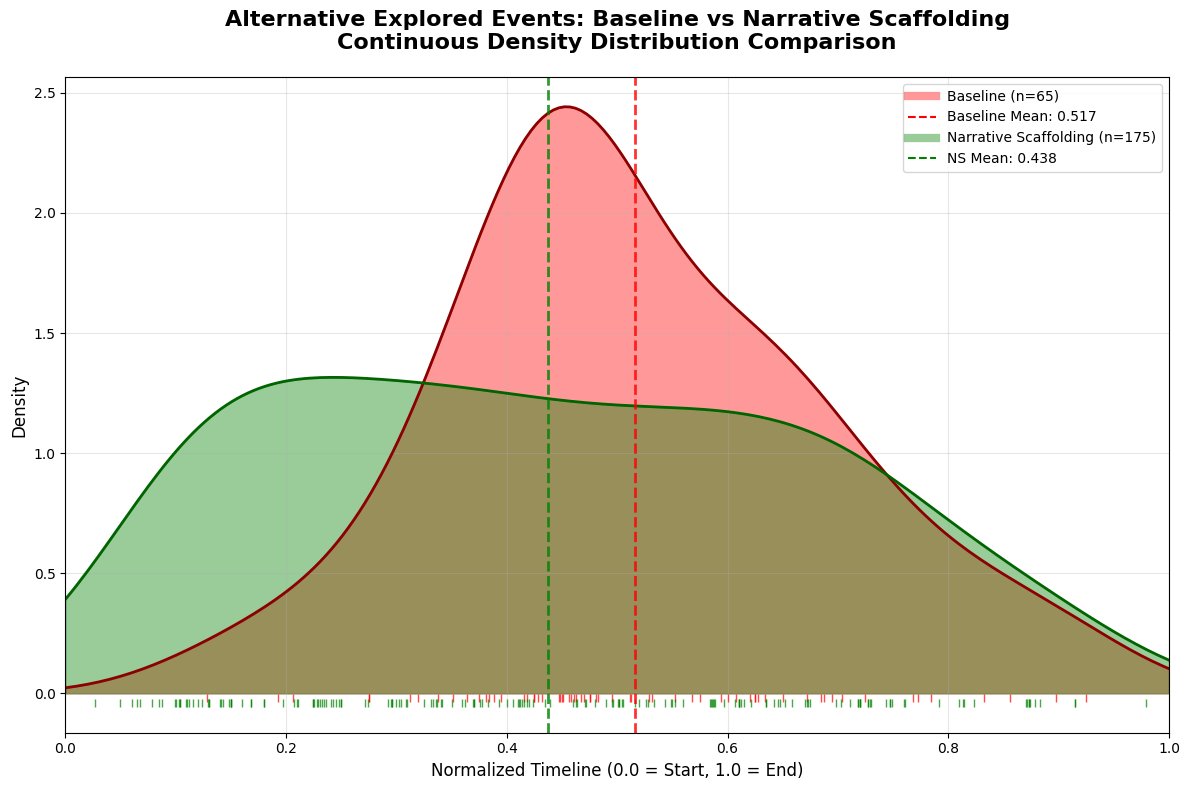


=== Statistical Comparison ===
Mann-Whitney U test: statistic=6874.000, p-value=0.0131
Kolmogorov-Smirnov test: statistic=0.289, p-value=0.0005
Effect size (Cohen's d): -0.382
Effect size interpretation: small
Statistical significance (α=0.05): significant


In [26]:
# Create combined continuous overlay density plot for comparison
plt.figure(figsize=(12, 8))

x_range = np.linspace(0, 1, 200)

# Plot baseline and NS with continuous KDE on the same axes
if alternative_events['baseline'] and len(alternative_events['baseline']) > 1:
    kde_baseline = gaussian_kde(alternative_events['baseline'])
    density_baseline = kde_baseline(x_range)
    
    plt.fill_between(x_range, density_baseline, alpha=0.4, color='red', 
                     label=f'Baseline (n={len(alternative_events["baseline"])})')
    plt.plot(x_range, density_baseline, color='darkred', linewidth=2)
    
    # Add rug plot
    plt.plot(alternative_events['baseline'], 
             np.full_like(alternative_events['baseline'], -0.02), 
             '|', color='red', markersize=6, alpha=0.7)

elif alternative_events['baseline'] and len(alternative_events['baseline']) == 1:
    plt.axvline(alternative_events['baseline'][0], color='red', linewidth=3, alpha=0.8,
                label=f'Baseline (n=1)')

if alternative_events['ns'] and len(alternative_events['ns']) > 1:
    kde_ns = gaussian_kde(alternative_events['ns'])
    density_ns = kde_ns(x_range)
    
    plt.fill_between(x_range, density_ns, alpha=0.4, color='green', 
                     label=f'Narrative Scaffolding (n={len(alternative_events["ns"])})')
    plt.plot(x_range, density_ns, color='darkgreen', linewidth=2)
    
    # Add rug plot
    plt.plot(alternative_events['ns'], 
             np.full_like(alternative_events['ns'], -0.04), 
             '|', color='green', markersize=6, alpha=0.7)

elif alternative_events['ns'] and len(alternative_events['ns']) == 1:
    plt.axvline(alternative_events['ns'][0], color='green', linewidth=3, alpha=0.8,
                label=f'Narrative Scaffolding (n=1)')

plt.title('Alternative Explored Events: Baseline vs Narrative Scaffolding\nContinuous Density Distribution Comparison', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Normalized Timeline (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)

# Add vertical lines for means if data exists
if alternative_events['baseline']:
    baseline_mean = np.mean(alternative_events['baseline'])
    plt.axvline(baseline_mean, color='red', linestyle='--', alpha=0.8, linewidth=2)

if alternative_events['ns']:
    ns_mean = np.mean(alternative_events['ns'])
    plt.axvline(ns_mean, color='green', linestyle='--', alpha=0.8, linewidth=2)

# Create custom legend
legend_elements = []
if alternative_events['baseline']:
    baseline_mean = np.mean(alternative_events['baseline'])
    legend_elements.extend([
        plt.Line2D([0], [0], color='red', alpha=0.4, linewidth=6, 
                   label=f'Baseline (n={len(alternative_events["baseline"])})'),
        plt.Line2D([0], [0], color='red', linestyle='--', 
                   label=f'Baseline Mean: {baseline_mean:.3f}')
    ])

if alternative_events['ns']:
    ns_mean = np.mean(alternative_events['ns'])
    legend_elements.extend([
        plt.Line2D([0], [0], color='green', alpha=0.4, linewidth=6, 
                   label=f'Narrative Scaffolding (n={len(alternative_events["ns"])})'),
        plt.Line2D([0], [0], color='green', linestyle='--', 
                   label=f'NS Mean: {ns_mean:.3f}')
    ])

if legend_elements:
    plt.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

# Statistical comparison if both conditions have data
if alternative_events['baseline'] and alternative_events['ns']:
    print("\n=== Statistical Comparison ===")
    
    # Mann-Whitney U test (non-parametric)
    statistic, p_value = stats.mannwhitneyu(alternative_events['baseline'], alternative_events['ns'])
    print(f"Mann-Whitney U test: statistic={statistic:.3f}, p-value={p_value:.4f}")
    
    # Kolmogorov-Smirnov test
    ks_stat, ks_p = stats.ks_2samp(alternative_events['baseline'], alternative_events['ns'])
    print(f"Kolmogorov-Smirnov test: statistic={ks_stat:.3f}, p-value={ks_p:.4f}")
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((np.std(alternative_events['baseline'])**2 + np.std(alternative_events['ns'])**2) / 2)
    cohen_d = (np.mean(alternative_events['ns']) - np.mean(alternative_events['baseline'])) / pooled_std
    print(f"Effect size (Cohen's d): {cohen_d:.3f}")
    
    if abs(cohen_d) < 0.2:
        effect_label = "negligible"
    elif abs(cohen_d) < 0.5:
        effect_label = "small"
    elif abs(cohen_d) < 0.8:
        effect_label = "medium" 
    else:
        effect_label = "large"
    
    print(f"Effect size interpretation: {effect_label}")
    
    significance = "significant" if p_value < 0.05 else "not significant"
    print(f"Statistical significance (α=0.05): {significance}")
else:
    print("\n=== Statistical Comparison ===")
    print("Cannot perform statistical comparison - one or both conditions have no alternative_explored events")

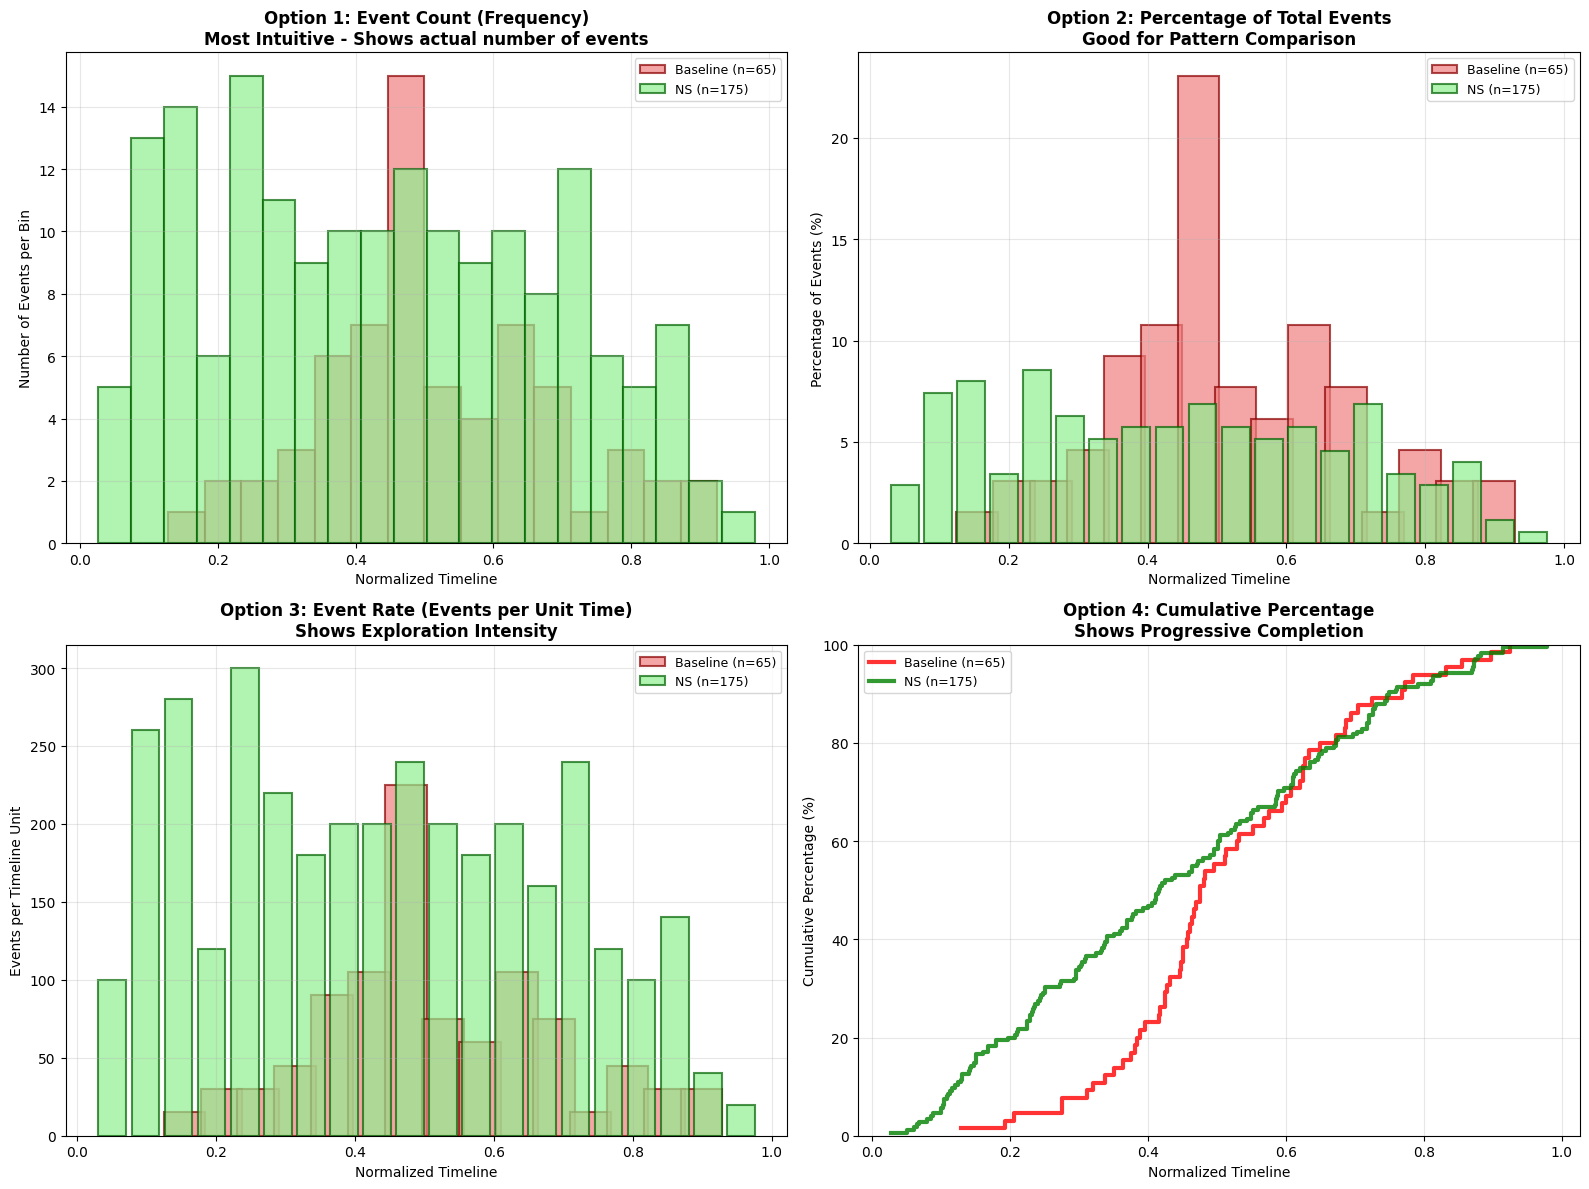

=== Y-Axis Options Explained ===

1. EVENT COUNT (Frequency) - MOST INTUITIVE
   • Y-axis: Number of events in each time bin
   • Interpretation: 'How many events happened in this time period?'
   • Best for: Understanding actual volume differences

2. PERCENTAGE OF TOTAL EVENTS
   • Y-axis: What % of all events occurred in each bin
   • Interpretation: 'What portion of exploration happened here?'
   • Best for: Comparing patterns regardless of total volume

3. EVENT RATE (Events per unit time)
   • Y-axis: Events divided by bin width
   • Interpretation: 'How intense was exploration in this period?'
   • Best for: Understanding exploration intensity

4. CUMULATIVE PERCENTAGE
   • Y-axis: Running total as percentage
   • Interpretation: 'What % of exploration was complete by this time?'
   • Best for: Understanding progression patterns

5. DENSITY (KDE) - LEAST INTUITIVE
   • Y-axis: Probability density function values
   • Interpretation: Complex mathematical concept
   • Best for: St

In [27]:
# Demonstrate different y-axis options for better interpretability
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Event Count (Frequency) - Most Intuitive
if alternative_events['baseline']:
    counts_b, bins_b, patches_b = ax1.hist(alternative_events['baseline'], bins=15, 
                                          alpha=0.7, color='lightcoral', edgecolor='darkred', 
                                          linewidth=1.5, label=f'Baseline (n={len(alternative_events["baseline"])})')
if alternative_events['ns']:
    counts_ns, bins_ns, patches_ns = ax1.hist(alternative_events['ns'], bins=20, 
                                             alpha=0.7, color='lightgreen', edgecolor='darkgreen', 
                                             linewidth=1.5, label=f'NS (n={len(alternative_events["ns"])})')

ax1.set_title('Option 1: Event Count (Frequency)\nMost Intuitive - Shows actual number of events', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Normalized Timeline', fontsize=10)
ax1.set_ylabel('Number of Events per Bin', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Percentage of Total Events - Good for Comparison
if alternative_events['baseline']:
    counts_b_pct = (counts_b / len(alternative_events['baseline'])) * 100
    bin_centers_b = (bins_b[:-1] + bins_b[1:]) / 2
    ax2.bar(bin_centers_b, counts_b_pct, width=0.06, alpha=0.7, color='lightcoral', 
            edgecolor='darkred', linewidth=1.5, label=f'Baseline (n={len(alternative_events["baseline"])})')

if alternative_events['ns']:
    counts_ns_pct = (counts_ns / len(alternative_events['ns'])) * 100
    bin_centers_ns = (bins_ns[:-1] + bins_ns[1:]) / 2
    ax2.bar(bin_centers_ns, counts_ns_pct, width=0.04, alpha=0.7, color='lightgreen', 
            edgecolor='darkgreen', linewidth=1.5, label=f'NS (n={len(alternative_events["ns"])})')

ax2.set_title('Option 2: Percentage of Total Events\nGood for Pattern Comparison', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Normalized Timeline', fontsize=10)
ax2.set_ylabel('Percentage of Events (%)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Events per Unit Time (Rate) - Shows Intensity
bin_width = 1.0 / 15  # Approximate bin width for baseline
if alternative_events['baseline']:
    rate_b = counts_b / bin_width  # Events per unit timeline
    bin_centers_b = (bins_b[:-1] + bins_b[1:]) / 2
    ax3.bar(bin_centers_b, rate_b, width=0.06, alpha=0.7, color='lightcoral', 
            edgecolor='darkred', linewidth=1.5, label=f'Baseline (n={len(alternative_events["baseline"])})')

bin_width = 1.0 / 20  # Approximate bin width for NS
if alternative_events['ns']:
    rate_ns = counts_ns / bin_width
    bin_centers_ns = (bins_ns[:-1] + bins_ns[1:]) / 2
    ax3.bar(bin_centers_ns, rate_ns, width=0.04, alpha=0.7, color='lightgreen', 
            edgecolor='darkgreen', linewidth=1.5, label=f'NS (n={len(alternative_events["ns"])})')

ax3.set_title('Option 3: Event Rate (Events per Unit Time)\nShows Exploration Intensity', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Normalized Timeline', fontsize=10)
ax3.set_ylabel('Events per Timeline Unit', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Cumulative Percentage - Shows Progressive Patterns
if alternative_events['baseline']:
    baseline_sorted = sorted(alternative_events['baseline'])
    baseline_cum_pct = np.arange(1, len(baseline_sorted) + 1) / len(baseline_sorted) * 100
    ax4.step(baseline_sorted, baseline_cum_pct, where='post', color='red', linewidth=3, 
             alpha=0.8, label=f'Baseline (n={len(alternative_events["baseline"])})')

if alternative_events['ns']:
    ns_sorted = sorted(alternative_events['ns'])
    ns_cum_pct = np.arange(1, len(ns_sorted) + 1) / len(ns_sorted) * 100
    ax4.step(ns_sorted, ns_cum_pct, where='post', color='green', linewidth=3, 
             alpha=0.8, label=f'NS (n={len(alternative_events["ns"])})')

ax4.set_title('Option 4: Cumulative Percentage\nShows Progressive Completion', 
              fontsize=12, fontweight='bold')
ax4.set_xlabel('Normalized Timeline', fontsize=10)
ax4.set_ylabel('Cumulative Percentage (%)', fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Explain each y-axis option
print("=== Y-Axis Options Explained ===")
print()
print("1. EVENT COUNT (Frequency) - MOST INTUITIVE")
print("   • Y-axis: Number of events in each time bin")
print("   • Interpretation: 'How many events happened in this time period?'")
print("   • Best for: Understanding actual volume differences")
print()
print("2. PERCENTAGE OF TOTAL EVENTS")
print("   • Y-axis: What % of all events occurred in each bin")
print("   • Interpretation: 'What portion of exploration happened here?'")
print("   • Best for: Comparing patterns regardless of total volume")
print()
print("3. EVENT RATE (Events per unit time)")
print("   • Y-axis: Events divided by bin width")
print("   • Interpretation: 'How intense was exploration in this period?'")
print("   • Best for: Understanding exploration intensity")
print()
print("4. CUMULATIVE PERCENTAGE")
print("   • Y-axis: Running total as percentage")
print("   • Interpretation: 'What % of exploration was complete by this time?'")
print("   • Best for: Understanding progression patterns")
print()
print("5. DENSITY (KDE) - LEAST INTUITIVE")
print("   • Y-axis: Probability density function values")
print("   • Interpretation: Complex mathematical concept")
print("   • Best for: Statistical analysis, but confusing for most users")

# Compare the clarity
print("\n=== Recommendation ===")
print("For most research presentations and papers:")
print("  BEST: Event Count (Option 1) - Everyone understands 'number of events'")
print("  GOOD: Percentage (Option 2) - Good for pattern comparison")
print("  AVOID: Density - Mathematically correct but confusing")

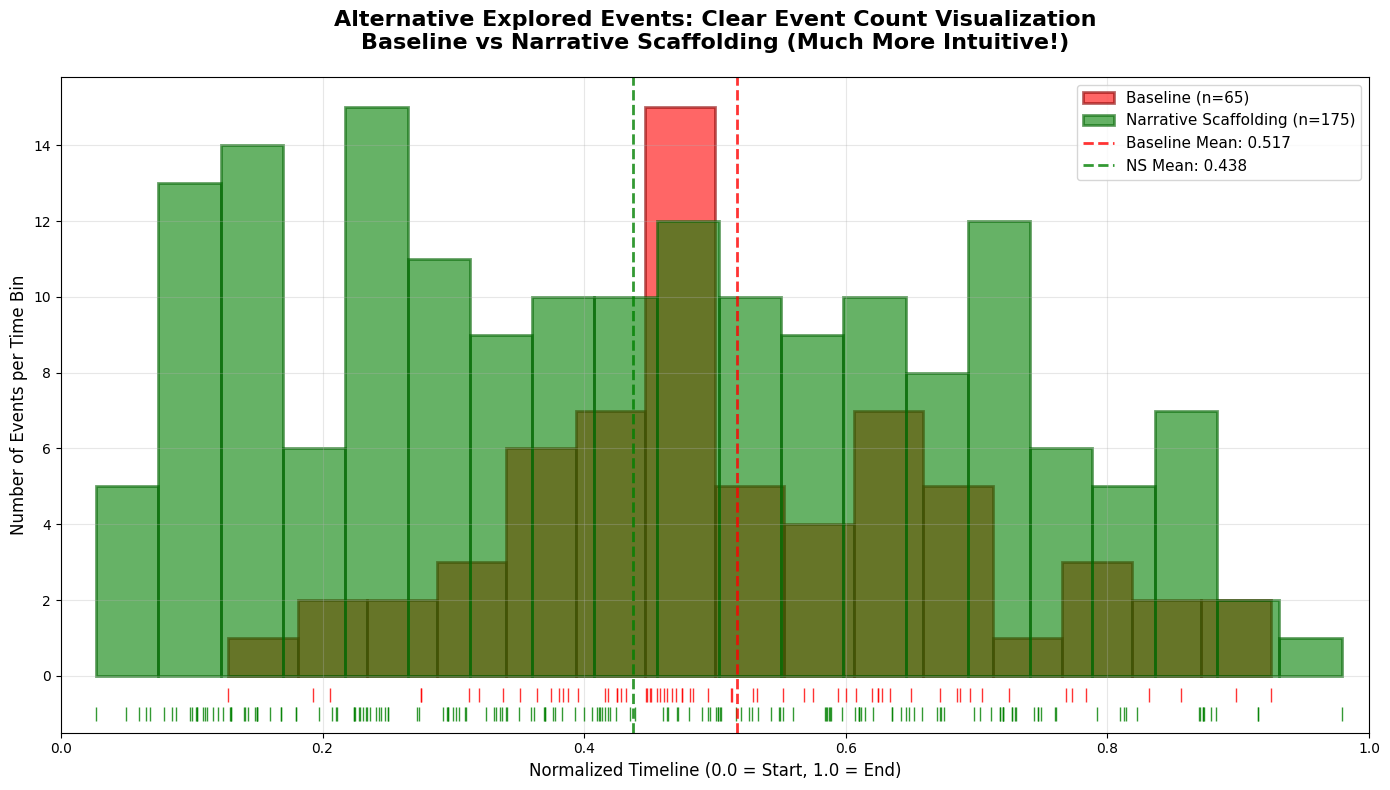

=== Clear Interpretation with Event Count Y-Axis ===
Peak activity (highest bins):
  Baseline: 15 events in busiest time period
  NS: 15 events in busiest time period
  NS has 1.0x more events in peak periods

Total exploration volume:
  Baseline: 65 events across all participants
  NS: 175 events across all participants
  Volume ratio: 2.7x more NS events

What this means:
  • NS participants explore 2.7x more alternatives
  • Peak periods show 1.0x higher activity with NS
  • The height differences directly show volume differences
  • No confusing 'density' math - just straightforward event counts!

✅ RECOMMENDATION: Use 'Number of Events' for y-axis instead of 'Density'
   Everyone understands event counts, but density is mathematically abstract.


In [28]:
# Create the BEST visualization using Event Count (most intuitive)
plt.figure(figsize=(14, 8))

# Use event count instead of density - much clearer!
if alternative_events['baseline']:
    counts_b, bins_b, patches_b = plt.hist(alternative_events['baseline'], bins=15, 
                                          alpha=0.6, color='red', edgecolor='darkred', 
                                          linewidth=2, label=f'Baseline (n={len(alternative_events["baseline"])})')
    
    # Add individual event markers
    plt.plot(alternative_events['baseline'], 
             np.full_like(alternative_events['baseline'], -0.5), 
             '|', color='red', markersize=10, alpha=0.8)

if alternative_events['ns']:
    counts_ns, bins_ns, patches_ns = plt.hist(alternative_events['ns'], bins=20, 
                                             alpha=0.6, color='green', edgecolor='darkgreen', 
                                             linewidth=2, label=f'Narrative Scaffolding (n={len(alternative_events["ns"])})')
    
    # Add individual event markers
    plt.plot(alternative_events['ns'], 
             np.full_like(alternative_events['ns'], -1), 
             '|', color='green', markersize=10, alpha=0.8)

# Add mean lines
if alternative_events['baseline']:
    baseline_mean = np.mean(alternative_events['baseline'])
    plt.axvline(baseline_mean, color='red', linestyle='--', linewidth=2, alpha=0.8,
                label=f'Baseline Mean: {baseline_mean:.3f}')

if alternative_events['ns']:
    ns_mean = np.mean(alternative_events['ns'])
    plt.axvline(ns_mean, color='green', linestyle='--', linewidth=2, alpha=0.8,
                label=f'NS Mean: {ns_mean:.3f}')

plt.title('Alternative Explored Events: Clear Event Count Visualization\nBaseline vs Narrative Scaffolding (Much More Intuitive!)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Normalized Timeline (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Number of Events per Time Bin', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(bottom=-1.5)

plt.tight_layout()
plt.show()

# Show clear interpretation
print("=== Clear Interpretation with Event Count Y-Axis ===")
if alternative_events['baseline'] and alternative_events['ns']:
    max_baseline = max(counts_b) if 'counts_b' in locals() and len(counts_b) > 0 else 0
    max_ns = max(counts_ns) if 'counts_ns' in locals() and len(counts_ns) > 0 else 0
    
    print(f"Peak activity (highest bins):")
    print(f"  Baseline: {max_baseline:.0f} events in busiest time period")
    print(f"  NS: {max_ns:.0f} events in busiest time period")
    
    if max_baseline > 0:
        print(f"  NS has {max_ns/max_baseline:.1f}x more events in peak periods")
    
    total_baseline = len(alternative_events['baseline'])
    total_ns = len(alternative_events['ns'])
    
    print(f"\nTotal exploration volume:")
    print(f"  Baseline: {total_baseline} events across all participants")
    print(f"  NS: {total_ns} events across all participants")
    print(f"  Volume ratio: {total_ns/total_baseline:.1f}x more NS events")
    
    print(f"\nWhat this means:")
    print(f"  • NS participants explore {total_ns/total_baseline:.1f}x more alternatives")
    print(f"  • Peak periods show {max_ns/max_baseline:.1f}x higher activity with NS")
    print(f"  • The height differences directly show volume differences")
    print(f"  • No confusing 'density' math - just straightforward event counts!")

print(f"\n✅ RECOMMENDATION: Use 'Number of Events' for y-axis instead of 'Density'")
print(f"   Everyone understands event counts, but density is mathematically abstract.")

## Cumulative Alternative Explored Events Analysis

Analyzing the cumulative progression of "alternative_explored" events over the normalized timeline, showing how participants accumulate alternatives throughout their sessions.

In [29]:
# Collect cumulative alternative_explored data for each participant
def collect_cumulative_alternative_data():
    """
    Collect cumulative alternative_explored events for each participant
    Returns: dict with participant-level cumulative data for baseline and NS
    """
    
    baseline_cumulative = {}
    ns_cumulative = {}
    
    event_folder = 'participant_events'
    baseline_files = glob.glob(f'{event_folder}/*_baseline.csv')
    ns_files = glob.glob(f'{event_folder}/*_ns.csv')
    
    # Process baseline files
    for file_path in baseline_files:
        try:
            participant_id = os.path.basename(file_path).replace('_baseline.csv', '')
            events_df = pd.read_csv(file_path)
            
            # Get all alternative_explored events
            alternative_events = events_df[events_df['event_type'] == 'alternative_explored']
            
            if not alternative_events.empty:
                timestamps = sorted(alternative_events['timestamp_normalized'].tolist())
                cumulative_counts = list(range(1, len(timestamps) + 1))
                baseline_cumulative[participant_id] = {
                    'timestamps': timestamps,
                    'cumulative': cumulative_counts
                }
            else:
                baseline_cumulative[participant_id] = {
                    'timestamps': [],
                    'cumulative': []
                }
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    # Process NS files
    for file_path in ns_files:
        try:
            participant_id = os.path.basename(file_path).replace('_ns.csv', '')
            events_df = pd.read_csv(file_path)
            
            # Get all alternative_explored events
            alternative_events = events_df[events_df['event_type'] == 'alternative_explored']
            
            if not alternative_events.empty:
                timestamps = sorted(alternative_events['timestamp_normalized'].tolist())
                cumulative_counts = list(range(1, len(timestamps) + 1))
                ns_cumulative[participant_id] = {
                    'timestamps': timestamps,
                    'cumulative': cumulative_counts
                }
            else:
                ns_cumulative[participant_id] = {
                    'timestamps': [],
                    'cumulative': []
                }
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    return baseline_cumulative, ns_cumulative

# Collect the cumulative data
baseline_cum_data, ns_cum_data = collect_cumulative_alternative_data()

print(f"Participants with baseline data: {len(baseline_cum_data)}")
print(f"Participants with NS data: {len(ns_cum_data)}")

# Calculate summary statistics
baseline_final_counts = []
ns_final_counts = []

for participant, data in baseline_cum_data.items():
    if data['cumulative']:
        baseline_final_counts.append(max(data['cumulative']))
    else:
        baseline_final_counts.append(0)

for participant, data in ns_cum_data.items():
    if data['cumulative']:
        ns_final_counts.append(max(data['cumulative']))
    else:
        ns_final_counts.append(0)

print(f"\nBaseline final counts per participant: {baseline_final_counts}")
print(f"NS final counts per participant: {ns_final_counts}")
print(f"Baseline total alternative_explored events: {sum(baseline_final_counts)}")
print(f"NS total alternative_explored events: {sum(ns_final_counts)}")
print(f"Baseline average per participant: {np.mean(baseline_final_counts):.2f}")
print(f"NS average per participant: {np.mean(ns_final_counts):.2f}")

Participants with baseline data: 20
Participants with NS data: 20

Baseline final counts per participant: [3, 7, 1, 3, 4, 7, 2, 4, 3, 2, 2, 4, 2, 2, 4, 5, 2, 2, 3, 3]
NS final counts per participant: [11, 7, 6, 7, 9, 15, 6, 9, 10, 8, 9, 18, 8, 6, 11, 7, 6, 7, 8, 7]
Baseline total alternative_explored events: 65
NS total alternative_explored events: 175
Baseline average per participant: 3.25
NS average per participant: 8.75


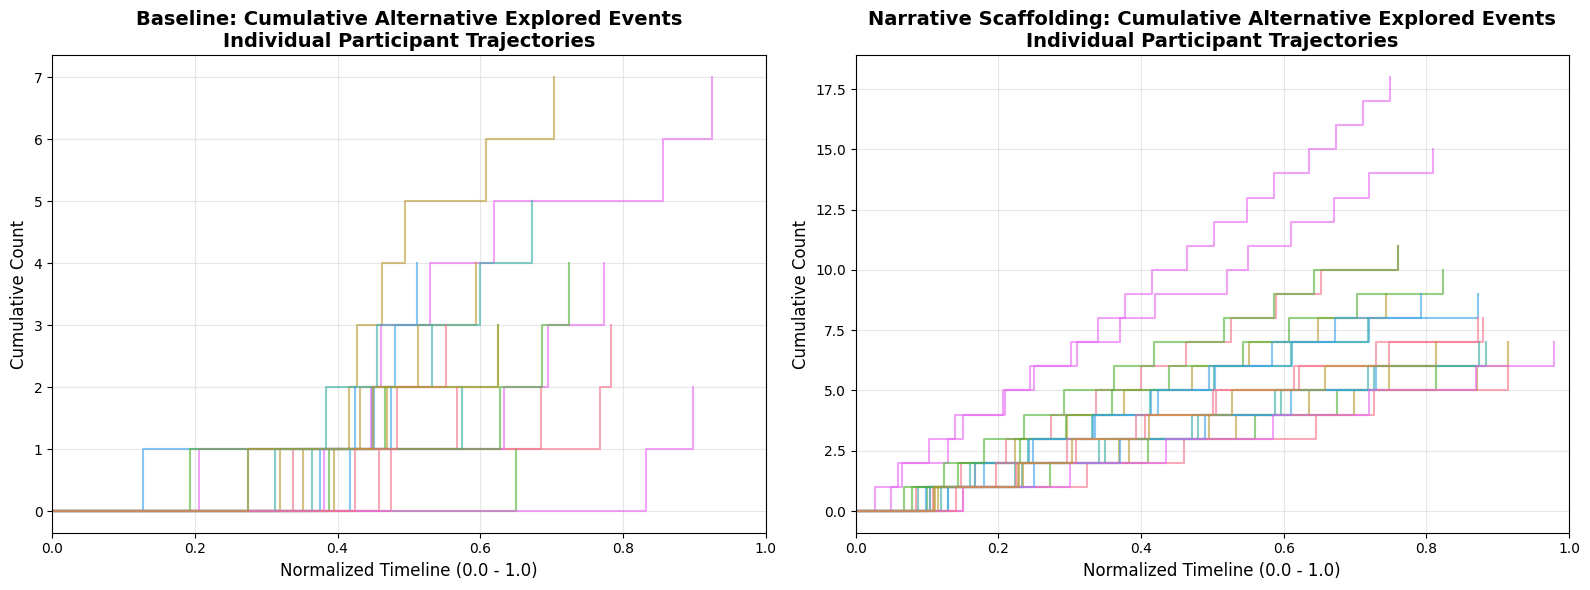

In [30]:
# Plot individual participant cumulative curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Baseline cumulative curves
for participant, data in baseline_cum_data.items():
    if data['timestamps']:
        # Add starting point at (0, 0)
        x_vals = [0] + data['timestamps']
        y_vals = [0] + data['cumulative']
        ax1.step(x_vals, y_vals, alpha=0.6, linewidth=1.5, where='post')

ax1.set_title('Baseline: Cumulative Alternative Explored Events\nIndividual Participant Trajectories', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
ax1.set_ylabel('Cumulative Count', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)

# NS cumulative curves
for participant, data in ns_cum_data.items():
    if data['timestamps']:
        # Add starting point at (0, 0)
        x_vals = [0] + data['timestamps']
        y_vals = [0] + data['cumulative']
        ax2.step(x_vals, y_vals, alpha=0.6, linewidth=1.5, where='post')

ax2.set_title('Narrative Scaffolding: Cumulative Alternative Explored Events\nIndividual Participant Trajectories', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
ax2.set_ylabel('Cumulative Count', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

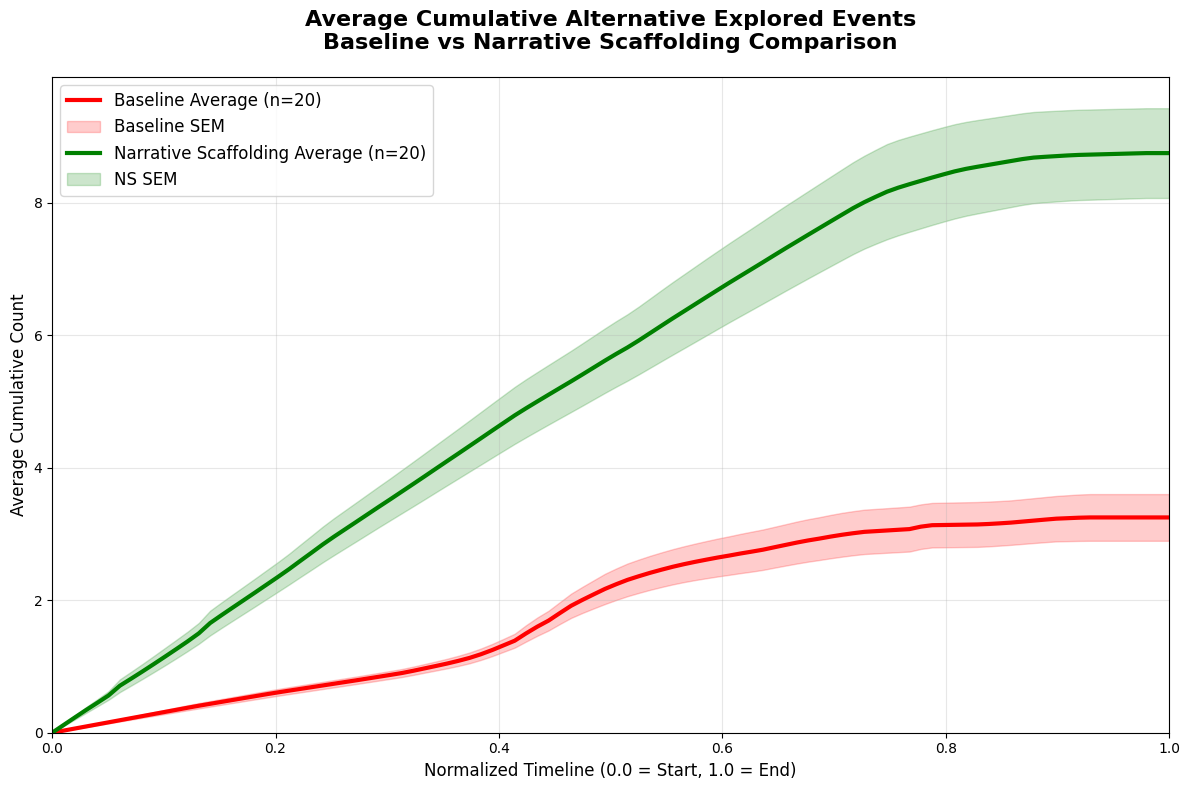


=== Final Cumulative Comparison ===
Baseline final average: 3.25 ± 0.35 (SEM)
NS final average: 8.75 ± 0.68 (SEM)
Difference (NS - Baseline): +5.50
t-test on final counts: t=7.016, p=0.0000
Effect size (Cohen's d): 2.276


In [31]:
# Calculate and plot average cumulative curves
def calculate_average_cumulative(cumulative_data, time_points=100):
    """
    Calculate average cumulative curve across all participants
    """
    time_grid = np.linspace(0, 1, time_points)
    cumulative_grid = np.zeros((len(cumulative_data), time_points))
    
    for i, (participant, data) in enumerate(cumulative_data.items()):
        if data['timestamps']:
            # Create step function for this participant
            x_vals = [0] + data['timestamps'] + [1.0]  # Add endpoints
            y_vals = [0] + data['cumulative'] + [data['cumulative'][-1]]  # Hold final value
            
            # Interpolate to common grid
            cumulative_grid[i, :] = np.interp(time_grid, x_vals, y_vals)
        # else: remains zeros (no events)
    
    return time_grid, cumulative_grid

# Calculate average curves
baseline_time, baseline_grid = calculate_average_cumulative(baseline_cum_data)
ns_time, ns_grid = calculate_average_cumulative(ns_cum_data)

# Calculate statistics
baseline_mean = np.mean(baseline_grid, axis=0)
baseline_std = np.std(baseline_grid, axis=0)
baseline_sem = baseline_std / np.sqrt(baseline_grid.shape[0])

ns_mean = np.mean(ns_grid, axis=0)
ns_std = np.std(ns_grid, axis=0)
ns_sem = ns_std / np.sqrt(ns_grid.shape[0])

# Plot average cumulative curves with confidence intervals
plt.figure(figsize=(12, 8))

# Baseline average curve
plt.plot(baseline_time, baseline_mean, color='red', linewidth=3, 
         label=f'Baseline Average (n={len(baseline_cum_data)})')
plt.fill_between(baseline_time, 
                 baseline_mean - baseline_sem, 
                 baseline_mean + baseline_sem, 
                 color='red', alpha=0.2, label='Baseline SEM')

# NS average curve
plt.plot(ns_time, ns_mean, color='green', linewidth=3, 
         label=f'Narrative Scaffolding Average (n={len(ns_cum_data)})')
plt.fill_between(ns_time, 
                 ns_mean - ns_sem, 
                 ns_mean + ns_sem, 
                 color='green', alpha=0.2, label='NS SEM')

plt.title('Average Cumulative Alternative Explored Events\nBaseline vs Narrative Scaffolding Comparison', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Normalized Timeline (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Average Cumulative Count', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

# Print final comparison
print(f"\n=== Final Cumulative Comparison ===")
print(f"Baseline final average: {baseline_mean[-1]:.2f} ± {baseline_sem[-1]:.2f} (SEM)")
print(f"NS final average: {ns_mean[-1]:.2f} ± {ns_sem[-1]:.2f} (SEM)")
print(f"Difference (NS - Baseline): {ns_mean[-1] - baseline_mean[-1]:+.2f}")

# Statistical test on final counts
if baseline_final_counts and ns_final_counts:
    t_stat, p_val = stats.ttest_ind(ns_final_counts, baseline_final_counts)
    print(f"t-test on final counts: t={t_stat:.3f}, p={p_val:.4f}")
    
    effect_size = (np.mean(ns_final_counts) - np.mean(baseline_final_counts)) / np.sqrt((np.std(ns_final_counts)**2 + np.std(baseline_final_counts)**2) / 2)
    print(f"Effect size (Cohen's d): {effect_size:.3f}")

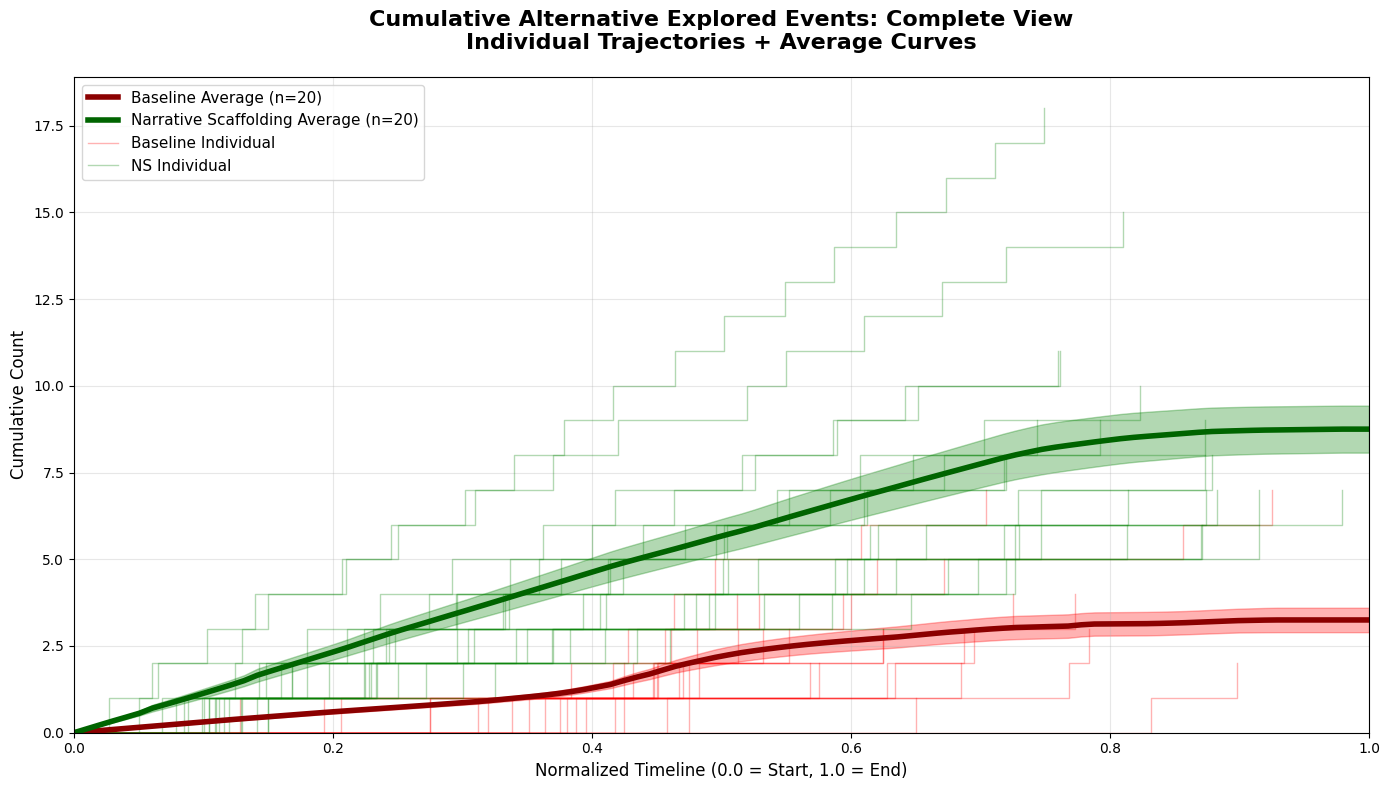


=== Cumulative Alternative Explored Events Summary ===
Condition       Total Events Avg/Participant Max Individual 
------------------------------------------------------------
Baseline        65           3.25            7              
Narrative Scaffolding 175          8.75            18             

NS/Baseline ratio: 2.69x more alternative exploration events


In [32]:
# Create combined overlay plot showing both individual trajectories and averages
plt.figure(figsize=(14, 8))

# Plot individual trajectories (lighter)
for participant, data in baseline_cum_data.items():
    if data['timestamps']:
        x_vals = [0] + data['timestamps']
        y_vals = [0] + data['cumulative']
        plt.step(x_vals, y_vals, color='red', alpha=0.3, linewidth=1, where='post')

for participant, data in ns_cum_data.items():
    if data['timestamps']:
        x_vals = [0] + data['timestamps']
        y_vals = [0] + data['cumulative']
        plt.step(x_vals, y_vals, color='green', alpha=0.3, linewidth=1, where='post')

# Plot average curves (prominent)
plt.plot(baseline_time, baseline_mean, color='darkred', linewidth=4, 
         label=f'Baseline Average (n={len(baseline_cum_data)})')
plt.fill_between(baseline_time, 
                 baseline_mean - baseline_sem, 
                 baseline_mean + baseline_sem, 
                 color='red', alpha=0.3)

plt.plot(ns_time, ns_mean, color='darkgreen', linewidth=4, 
         label=f'Narrative Scaffolding Average (n={len(ns_cum_data)})')
plt.fill_between(ns_time, 
                 ns_mean - ns_sem, 
                 ns_mean + ns_sem, 
                 color='green', alpha=0.3)

# Add individual trajectory indicators to legend
plt.plot([], [], color='red', alpha=0.3, linewidth=1, label='Baseline Individual')
plt.plot([], [], color='green', alpha=0.3, linewidth=1, label='NS Individual')

plt.title('Cumulative Alternative Explored Events: Complete View\nIndividual Trajectories + Average Curves', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Normalized Timeline (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Cumulative Count', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

# Summary table
print("\n=== Cumulative Alternative Explored Events Summary ===")
print(f"{'Condition':<15} {'Total Events':<12} {'Avg/Participant':<15} {'Max Individual':<15}")
print("-" * 60)
print(f"{'Baseline':<15} {sum(baseline_final_counts):<12} {np.mean(baseline_final_counts):<15.2f} {max(baseline_final_counts) if baseline_final_counts else 0:<15}")
print(f"{'Narrative Scaffolding':<15} {sum(ns_final_counts):<12} {np.mean(ns_final_counts):<15.2f} {max(ns_final_counts) if ns_final_counts else 0:<15}")

if baseline_final_counts and ns_final_counts:
    ratio = sum(ns_final_counts) / sum(baseline_final_counts) if sum(baseline_final_counts) > 0 else float('inf')
    print(f"\nNS/Baseline ratio: {ratio:.2f}x more alternative exploration events")

## Cumulative Density Distribution Analysis

Comparing the cumulative density functions (CDF) of alternative_explored events between conditions: 146 events (NS) vs 26 events (Baseline) over normalized timeline.

Baseline events for CDF: 65 events
NS events for CDF: 175 events


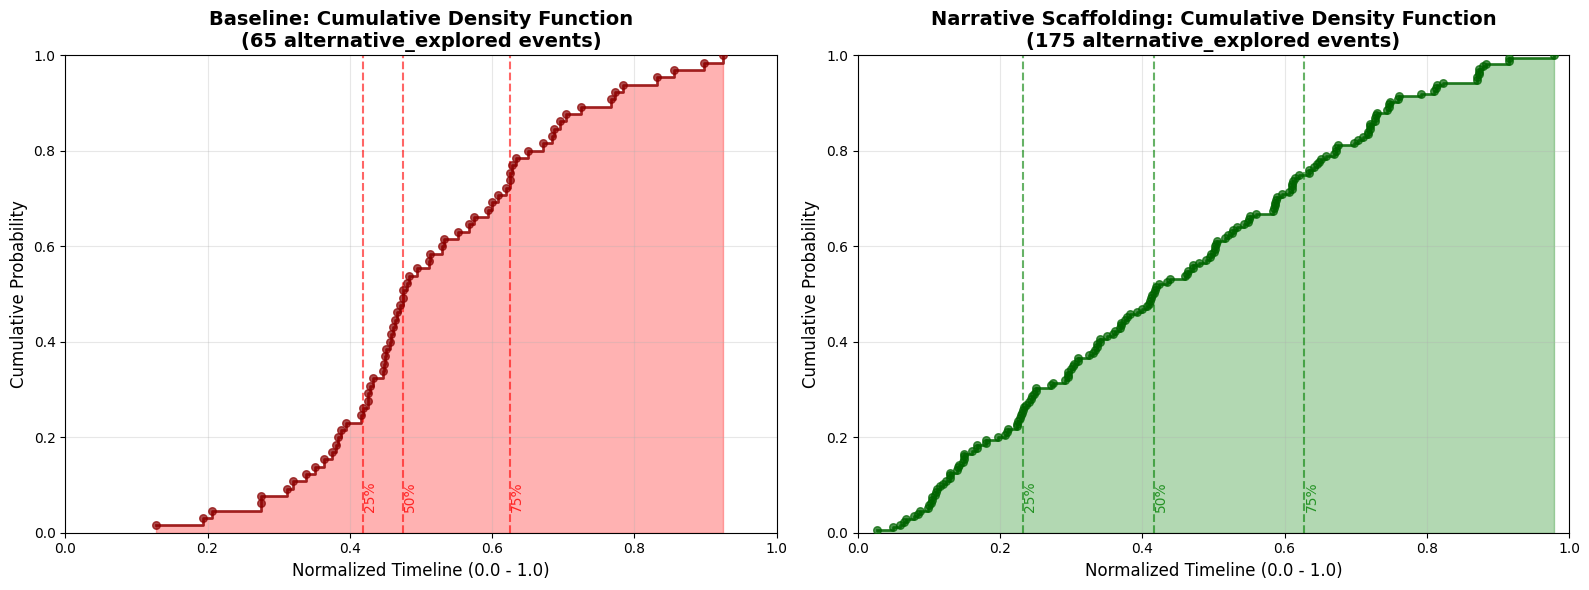


=== Cumulative Distribution Statistics ===
Baseline (n=65):
  25th percentile: 0.418
  50th percentile (median): 0.475
  75th percentile: 0.625
  Range: 0.128 - 0.925
Narrative Scaffolding (n=175):
  25th percentile: 0.232
  50th percentile (median): 0.416
  75th percentile: 0.628
  Range: 0.027 - 0.979


In [33]:
# Create cumulative density function (CDF) plots
from scipy.stats import gaussian_kde

# Prepare data for CDF analysis
baseline_events_sorted = sorted(alternative_events['baseline']) if alternative_events['baseline'] else []
ns_events_sorted = sorted(alternative_events['ns']) if alternative_events['ns'] else []

print(f"Baseline events for CDF: {len(baseline_events_sorted)} events")
print(f"NS events for CDF: {len(ns_events_sorted)} events")

# Create side-by-side cumulative density plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Baseline CDF
if baseline_events_sorted:
    # Calculate empirical CDF
    baseline_cdf_x = np.array(baseline_events_sorted)
    baseline_cdf_y = np.arange(1, len(baseline_events_sorted) + 1) / len(baseline_events_sorted)
    
    # Plot step function CDF
    ax1.step(baseline_cdf_x, baseline_cdf_y, where='post', color='darkred', linewidth=2, alpha=0.8)
    ax1.fill_between(baseline_cdf_x, baseline_cdf_y, step='post', alpha=0.3, color='red')
    
    # Add individual event markers
    ax1.scatter(baseline_cdf_x, baseline_cdf_y, color='darkred', s=30, alpha=0.7, zorder=5)
    
    ax1.set_title(f'Baseline: Cumulative Density Function\n({len(baseline_events_sorted)} alternative_explored events)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Cumulative Probability', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    
    # Add percentile lines
    percentiles = [0.25, 0.5, 0.75]
    for p in percentiles:
        if len(baseline_events_sorted) > 1:
            percentile_val = np.percentile(baseline_events_sorted, p * 100)
            ax1.axvline(percentile_val, color='red', linestyle='--', alpha=0.6)
            ax1.text(percentile_val, 0.05, f'{int(p*100)}%', rotation=90, 
                    color='red', fontsize=10, alpha=0.8)
else:
    ax1.text(0.5, 0.5, 'No alternative_explored\nevents in baseline', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Baseline: Cumulative Density Function', fontsize=14, fontweight='bold')

# NS CDF
if ns_events_sorted:
    # Calculate empirical CDF
    ns_cdf_x = np.array(ns_events_sorted)
    ns_cdf_y = np.arange(1, len(ns_events_sorted) + 1) / len(ns_events_sorted)
    
    # Plot step function CDF
    ax2.step(ns_cdf_x, ns_cdf_y, where='post', color='darkgreen', linewidth=2, alpha=0.8)
    ax2.fill_between(ns_cdf_x, ns_cdf_y, step='post', alpha=0.3, color='green')
    
    # Add individual event markers
    ax2.scatter(ns_cdf_x, ns_cdf_y, color='darkgreen', s=30, alpha=0.7, zorder=5)
    
    ax2.set_title(f'Narrative Scaffolding: Cumulative Density Function\n({len(ns_events_sorted)} alternative_explored events)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Cumulative Probability', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    
    # Add percentile lines
    percentiles = [0.25, 0.5, 0.75]
    for p in percentiles:
        if len(ns_events_sorted) > 1:
            percentile_val = np.percentile(ns_events_sorted, p * 100)
            ax2.axvline(percentile_val, color='green', linestyle='--', alpha=0.6)
            ax2.text(percentile_val, 0.05, f'{int(p*100)}%', rotation=90, 
                    color='green', fontsize=10, alpha=0.8)
else:
    ax2.text(0.5, 0.5, 'No alternative_explored\nevents in NS', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Narrative Scaffolding: Cumulative Density Function', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print CDF statistics
print("\n=== Cumulative Distribution Statistics ===")
if baseline_events_sorted:
    print(f"Baseline (n={len(baseline_events_sorted)}):")
    print(f"  25th percentile: {np.percentile(baseline_events_sorted, 25):.3f}")
    print(f"  50th percentile (median): {np.percentile(baseline_events_sorted, 50):.3f}")
    print(f"  75th percentile: {np.percentile(baseline_events_sorted, 75):.3f}")
    print(f"  Range: {min(baseline_events_sorted):.3f} - {max(baseline_events_sorted):.3f}")

if ns_events_sorted:
    print(f"Narrative Scaffolding (n={len(ns_events_sorted)}):")
    print(f"  25th percentile: {np.percentile(ns_events_sorted, 25):.3f}")
    print(f"  50th percentile (median): {np.percentile(ns_events_sorted, 50):.3f}")
    print(f"  75th percentile: {np.percentile(ns_events_sorted, 75):.3f}")
    print(f"  Range: {min(ns_events_sorted):.3f} - {max(ns_events_sorted):.3f}")

## Histogram with Density Overlay Analysis

Combining histogram bins with continuous density curves to show both discrete event distribution and underlying probability density for alternative_explored events.

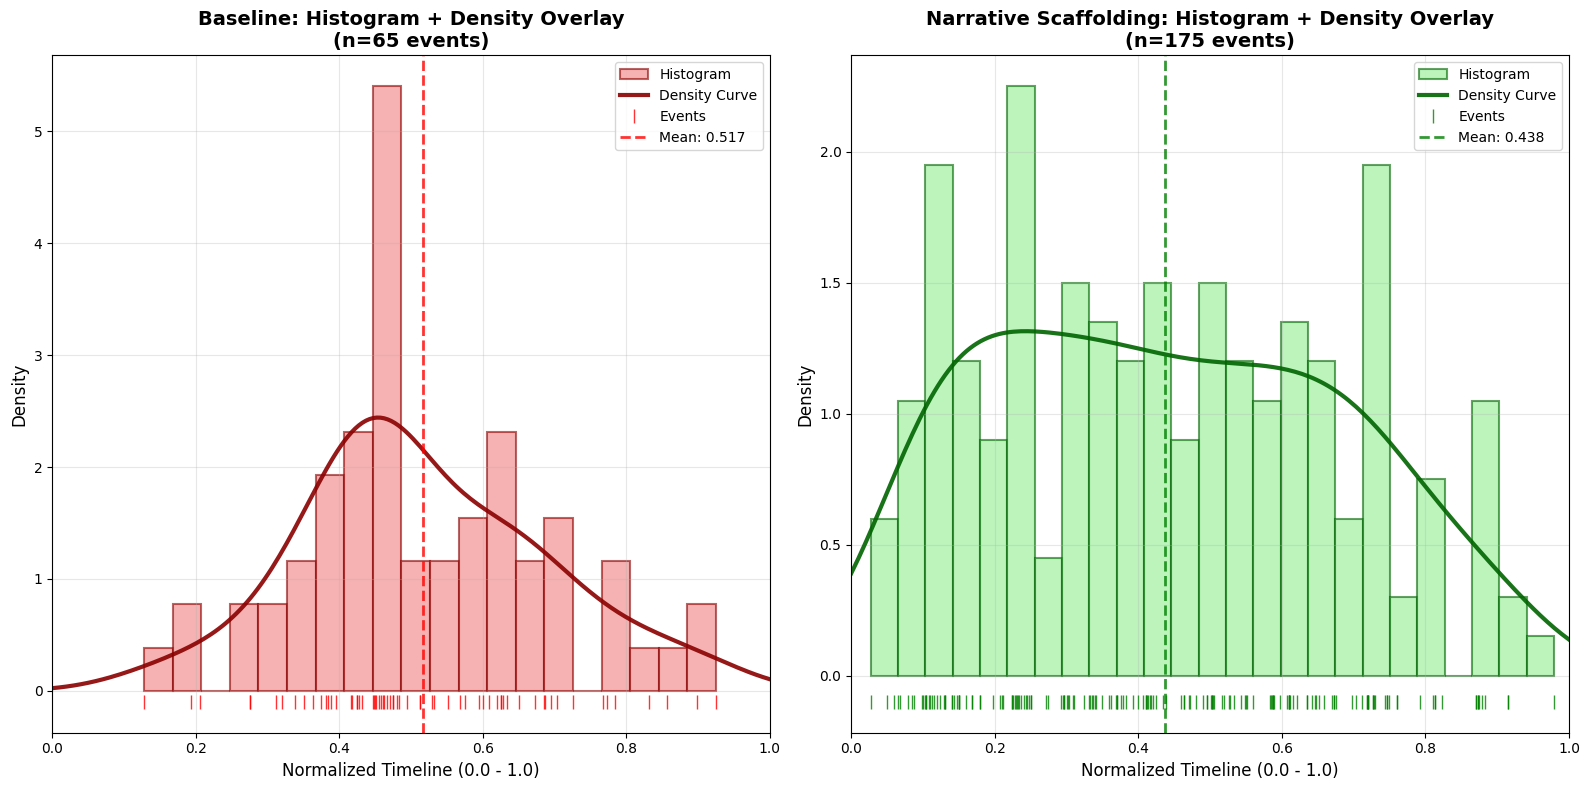


=== Histogram + Density Statistics ===
Baseline (n=65):
  Mean: 0.517
  Std: 0.168
  Min: 0.128
  Max: 0.925
Narrative Scaffolding (n=175):
  Mean: 0.438
  Std: 0.240
  Min: 0.027
  Max: 0.979


In [34]:
# Create side-by-side histograms with density overlays
from scipy.stats import gaussian_kde

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Baseline histogram with density overlay
if alternative_events['baseline'] and len(alternative_events['baseline']) > 1:
    # Create histogram
    counts, bins, patches = ax1.hist(alternative_events['baseline'], bins=20, density=True, 
                                    alpha=0.6, color='lightcoral', edgecolor='darkred', 
                                    linewidth=1.5, label='Histogram')
    
    # Create and overlay density curve
    kde_baseline = gaussian_kde(alternative_events['baseline'])
    x_smooth = np.linspace(0, 1, 200)
    density_baseline = kde_baseline(x_smooth)
    
    ax1.plot(x_smooth, density_baseline, color='darkred', linewidth=3, 
             label='Density Curve', alpha=0.9)
    
    # Add rug plot for individual events
    ax1.plot(alternative_events['baseline'], 
             np.full_like(alternative_events['baseline'], -0.1), 
             '|', color='red', markersize=10, alpha=0.8, label='Events')
    
    # Statistics
    mean_val = np.mean(alternative_events['baseline'])
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, alpha=0.8,
                label=f'Mean: {mean_val:.3f}')
    
    ax1.set_title(f'Baseline: Histogram + Density Overlay\n(n={len(alternative_events["baseline"])} events)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.legend(fontsize=10)
    
elif alternative_events['baseline'] and len(alternative_events['baseline']) == 1:
    # Single event
    ax1.axvline(alternative_events['baseline'][0], color='red', linewidth=4, alpha=0.8,
                label=f'Single Event: {alternative_events["baseline"][0]:.3f}')
    ax1.set_title('Baseline: Single Alternative Event', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.legend(fontsize=10)
else:
    ax1.text(0.5, 0.5, 'No alternative_explored\nevents in baseline', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Baseline: No Alternative Events', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)

# NS histogram with density overlay
if alternative_events['ns'] and len(alternative_events['ns']) > 1:
    # Create histogram
    counts, bins, patches = ax2.hist(alternative_events['ns'], bins=25, density=True, 
                                    alpha=0.6, color='lightgreen', edgecolor='darkgreen', 
                                    linewidth=1.5, label='Histogram')
    
    # Create and overlay density curve
    kde_ns = gaussian_kde(alternative_events['ns'])
    x_smooth = np.linspace(0, 1, 200)
    density_ns = kde_ns(x_smooth)
    
    ax2.plot(x_smooth, density_ns, color='darkgreen', linewidth=3, 
             label='Density Curve', alpha=0.9)
    
    # Add rug plot for individual events
    ax2.plot(alternative_events['ns'], 
             np.full_like(alternative_events['ns'], -0.1), 
             '|', color='green', markersize=10, alpha=0.8, label='Events')
    
    # Statistics
    mean_val = np.mean(alternative_events['ns'])
    ax2.axvline(mean_val, color='green', linestyle='--', linewidth=2, alpha=0.8,
                label=f'Mean: {mean_val:.3f}')
    
    ax2.set_title(f'Narrative Scaffolding: Histogram + Density Overlay\n(n={len(alternative_events["ns"])} events)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
    ax2.legend(fontsize=10)
    
elif alternative_events['ns'] and len(alternative_events['ns']) == 1:
    # Single event
    ax2.axvline(alternative_events['ns'][0], color='green', linewidth=4, alpha=0.8,
                label=f'Single Event: {alternative_events["ns"][0]:.3f}')
    ax2.set_title('Narrative Scaffolding: Single Alternative Event', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
    ax2.legend(fontsize=10)
else:
    ax2.text(0.5, 0.5, 'No alternative_explored\nevents in NS', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Narrative Scaffolding: No Alternative Events', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)

plt.tight_layout()
plt.show()

# Print histogram statistics
print("\n=== Histogram + Density Statistics ===")
if alternative_events['baseline']:
    print(f"Baseline (n={len(alternative_events['baseline'])}):")
    print(f"  Mean: {np.mean(alternative_events['baseline']):.3f}")
    print(f"  Std: {np.std(alternative_events['baseline']):.3f}")
    print(f"  Min: {min(alternative_events['baseline']):.3f}")
    print(f"  Max: {max(alternative_events['baseline']):.3f}")
    
if alternative_events['ns']:
    print(f"Narrative Scaffolding (n={len(alternative_events['ns'])}):")
    print(f"  Mean: {np.mean(alternative_events['ns']):.3f}")
    print(f"  Std: {np.std(alternative_events['ns']):.3f}")
    print(f"  Min: {min(alternative_events['ns']):.3f}")
    print(f"  Max: {max(alternative_events['ns']):.3f}")

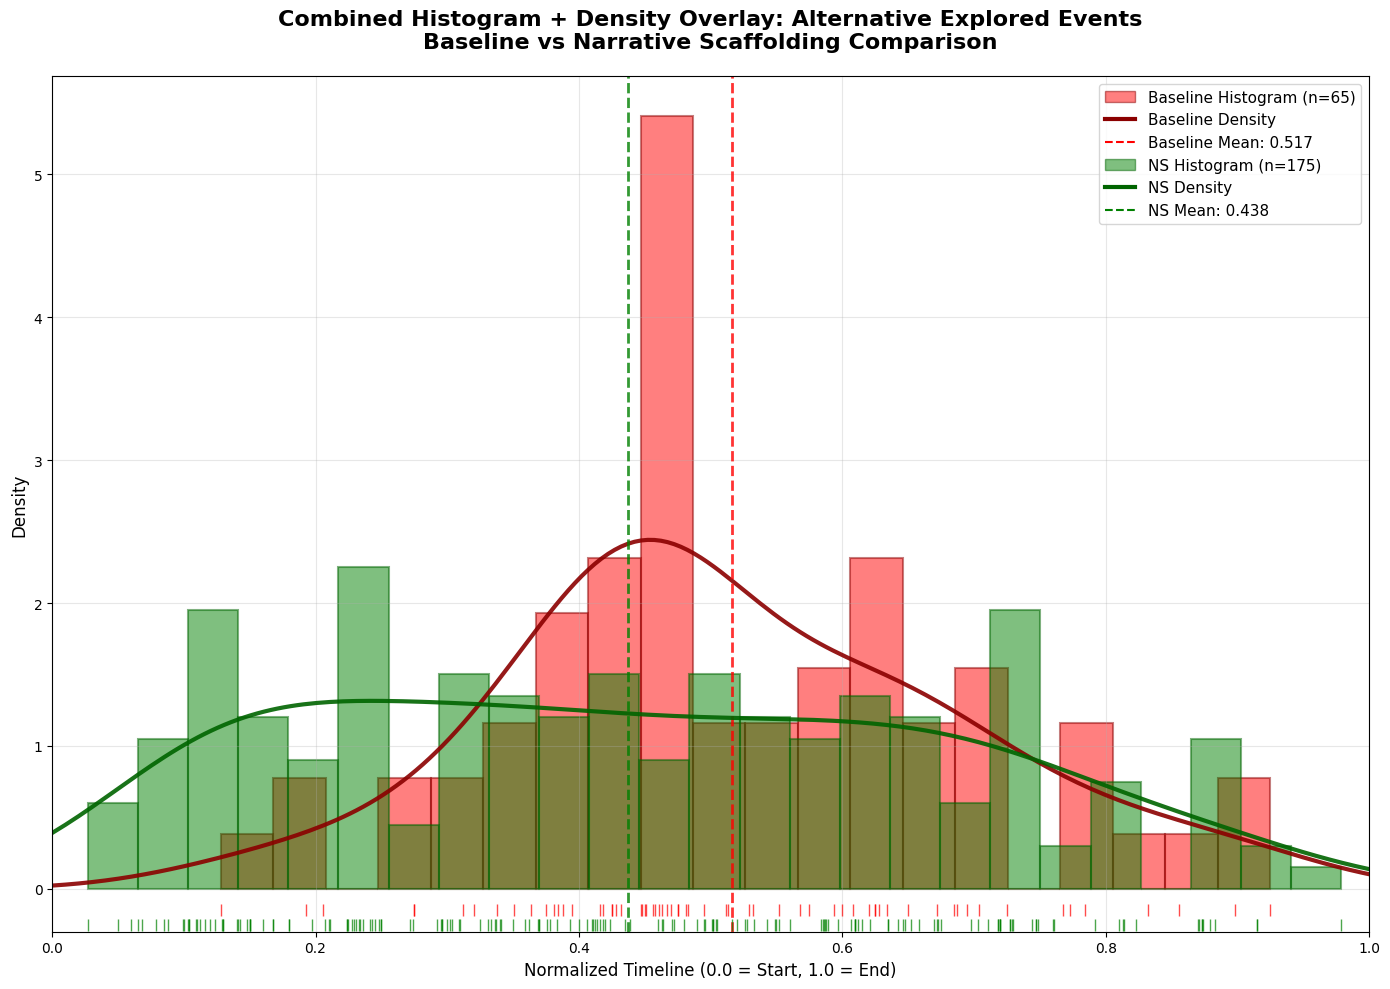


=== Histogram vs Density Comparison ===
Baseline: Mean=0.517, Std=0.168
NS: Mean=0.438, Std=0.240
Mean Difference (NS - Baseline): -0.079
Event Count Ratio (NS/Baseline): 2.7x
Distribution Range - Baseline: 0.797, NS: 0.952
Peak Activity Time - Baseline: 0.452
Peak Activity Time - NS: 0.241
Peak Time Difference (NS - Baseline): -0.211


In [35]:
# Create combined histogram with density overlay comparison
plt.figure(figsize=(14, 10))

# Create main plot
ax = plt.gca()

# Baseline histogram and density
if alternative_events['baseline'] and len(alternative_events['baseline']) > 1:
    # Histogram
    counts_b, bins_b, patches_b = ax.hist(alternative_events['baseline'], bins=20, density=True, 
                                         alpha=0.5, color='red', edgecolor='darkred', 
                                         linewidth=1.5, label=f'Baseline Histogram (n={len(alternative_events["baseline"])})')
    
    # Density curve
    kde_baseline = gaussian_kde(alternative_events['baseline'])
    x_smooth = np.linspace(0, 1, 200)
    density_baseline = kde_baseline(x_smooth)
    ax.plot(x_smooth, density_baseline, color='darkred', linewidth=3, 
            label='Baseline Density', alpha=0.9)
    
    # Rug plot
    ax.plot(alternative_events['baseline'], 
            np.full_like(alternative_events['baseline'], -0.15), 
            '|', color='red', markersize=8, alpha=0.7)
    
    # Mean line
    mean_baseline = np.mean(alternative_events['baseline'])
    ax.axvline(mean_baseline, color='red', linestyle='--', linewidth=2, alpha=0.8)

# NS histogram and density
if alternative_events['ns'] and len(alternative_events['ns']) > 1:
    # Histogram
    counts_ns, bins_ns, patches_ns = ax.hist(alternative_events['ns'], bins=25, density=True, 
                                            alpha=0.5, color='green', edgecolor='darkgreen', 
                                            linewidth=1.5, label=f'NS Histogram (n={len(alternative_events["ns"])})')
    
    # Density curve
    kde_ns = gaussian_kde(alternative_events['ns'])
    x_smooth = np.linspace(0, 1, 200)
    density_ns = kde_ns(x_smooth)
    ax.plot(x_smooth, density_ns, color='darkgreen', linewidth=3, 
            label='NS Density', alpha=0.9)
    
    # Rug plot
    ax.plot(alternative_events['ns'], 
            np.full_like(alternative_events['ns'], -0.25), 
            '|', color='green', markersize=8, alpha=0.7)
    
    # Mean line
    mean_ns = np.mean(alternative_events['ns'])
    ax.axvline(mean_ns, color='green', linestyle='--', linewidth=2, alpha=0.8)

# Formatting
ax.set_title('Combined Histogram + Density Overlay: Alternative Explored Events\nBaseline vs Narrative Scaffolding Comparison', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Normalized Timeline (0.0 = Start, 1.0 = End)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(bottom=-0.3)

# Enhanced legend with mean information
legend_elements = []
if alternative_events['baseline']:
    mean_baseline = np.mean(alternative_events['baseline'])
    legend_elements.extend([
        plt.Rectangle((0,0),1,1, facecolor='red', alpha=0.5, edgecolor='darkred',
                     label=f'Baseline Histogram (n={len(alternative_events["baseline"])})'),
        plt.Line2D([0], [0], color='darkred', linewidth=3,
                   label='Baseline Density'),
        plt.Line2D([0], [0], color='red', linestyle='--',
                   label=f'Baseline Mean: {mean_baseline:.3f}')
    ])

if alternative_events['ns']:
    mean_ns = np.mean(alternative_events['ns'])
    legend_elements.extend([
        plt.Rectangle((0,0),1,1, facecolor='green', alpha=0.5, edgecolor='darkgreen',
                     label=f'NS Histogram (n={len(alternative_events["ns"])})'),
        plt.Line2D([0], [0], color='darkgreen', linewidth=3,
                   label='NS Density'),
        plt.Line2D([0], [0], color='green', linestyle='--',
                   label=f'NS Mean: {mean_ns:.3f}')
    ])

if legend_elements:
    ax.legend(handles=legend_elements, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

# Print comparative analysis
print("\n=== Histogram vs Density Comparison ===")
if alternative_events['baseline'] and alternative_events['ns']:
    baseline_mean = np.mean(alternative_events['baseline'])
    ns_mean = np.mean(alternative_events['ns'])
    baseline_std = np.std(alternative_events['baseline'])
    ns_std = np.std(alternative_events['ns'])
    
    print(f"Baseline: Mean={baseline_mean:.3f}, Std={baseline_std:.3f}")
    print(f"NS: Mean={ns_mean:.3f}, Std={ns_std:.3f}")
    print(f"Mean Difference (NS - Baseline): {ns_mean - baseline_mean:+.3f}")
    print(f"Event Count Ratio (NS/Baseline): {len(alternative_events['ns'])/len(alternative_events['baseline']):.1f}x")
    
    # Distribution shape comparison
    baseline_range = max(alternative_events['baseline']) - min(alternative_events['baseline'])
    ns_range = max(alternative_events['ns']) - min(alternative_events['ns'])
    print(f"Distribution Range - Baseline: {baseline_range:.3f}, NS: {ns_range:.3f}")
    
    # Peak analysis using KDE
    if len(alternative_events['baseline']) > 1:
        kde_b = gaussian_kde(alternative_events['baseline'])
        x_grid = np.linspace(0, 1, 200)
        density_b = kde_b(x_grid)
        baseline_peak = x_grid[np.argmax(density_b)]
        print(f"Peak Activity Time - Baseline: {baseline_peak:.3f}")
    
    if len(alternative_events['ns']) > 1:
        kde_ns = gaussian_kde(alternative_events['ns'])
        density_ns = kde_ns(x_grid)
        ns_peak = x_grid[np.argmax(density_ns)]
        print(f"Peak Activity Time - NS: {ns_peak:.3f}")
        
        if len(alternative_events['baseline']) > 1:
            print(f"Peak Time Difference (NS - Baseline): {ns_peak - baseline_peak:+.3f}")

## Frequency-Based Analysis: Preserving Volume Differences

Creating frequency histograms and scaled KDE plots that show the true magnitude difference between n=146 (NS) and n=26 (Baseline) events, rather than normalizing to equal areas.

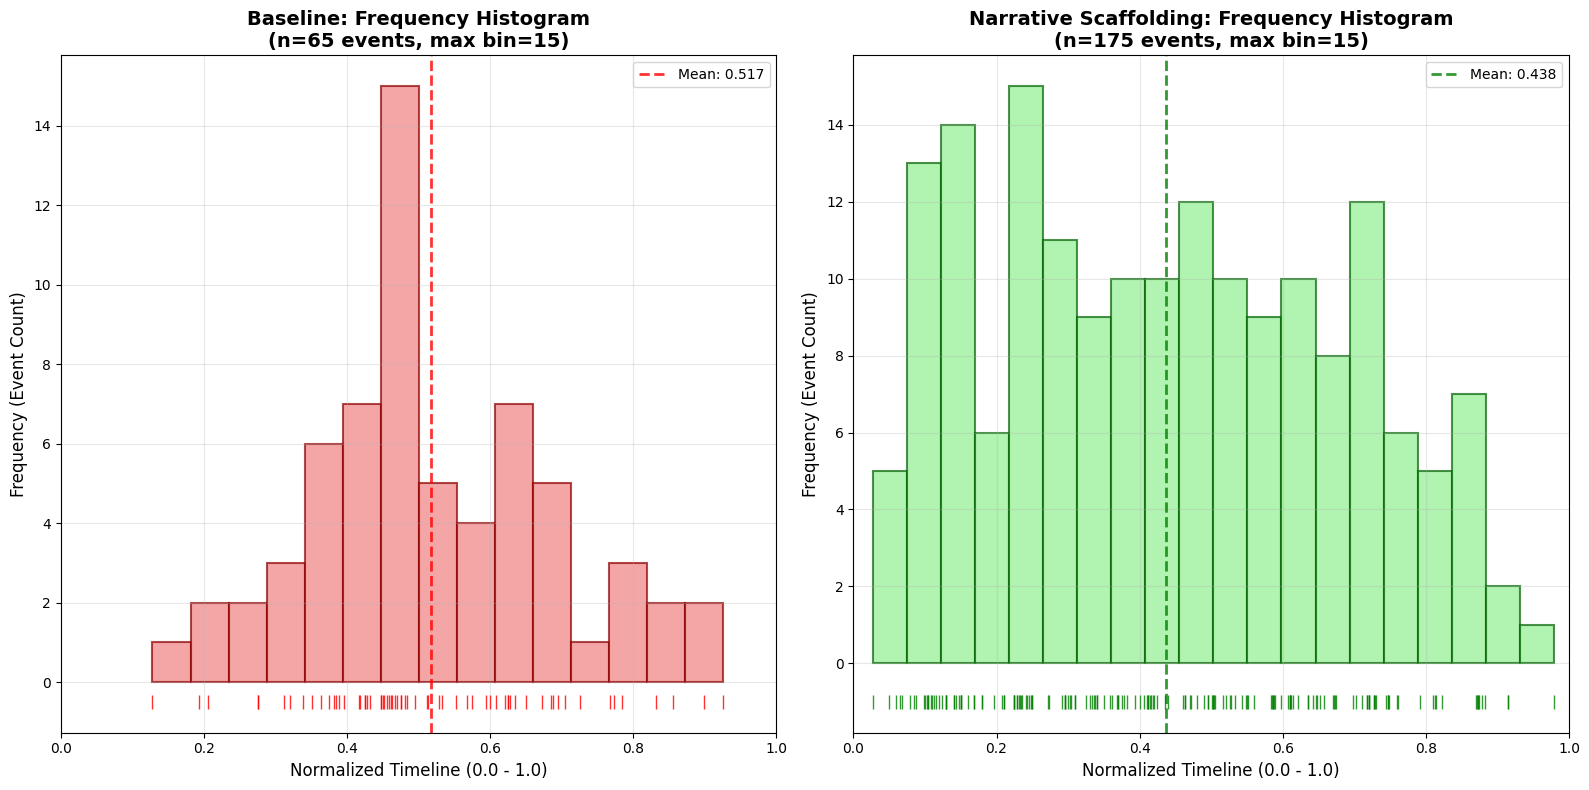


=== Frequency Histogram Comparison ===
Baseline total events: 65
NS total events: 175
Volume ratio (NS/Baseline): 2.7x
Maximum bin count - Baseline: 15
Maximum bin count - NS: 15
Peak bin ratio (NS/Baseline): 1.0x


In [36]:
# Create frequency histograms (not density) to show true volume differences
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Baseline frequency histogram
if alternative_events['baseline']:
    counts_b, bins_b, patches_b = ax1.hist(alternative_events['baseline'], bins=15, 
                                          alpha=0.7, color='lightcoral', edgecolor='darkred', 
                                          linewidth=1.5)
    
    # Add individual event markers
    ax1.plot(alternative_events['baseline'], 
             np.full_like(alternative_events['baseline'], -0.5), 
             '|', color='red', markersize=10, alpha=0.8)
    
    # Statistics
    mean_baseline = np.mean(alternative_events['baseline'])
    ax1.axvline(mean_baseline, color='red', linestyle='--', linewidth=2, alpha=0.8,
                label=f'Mean: {mean_baseline:.3f}')
    
    max_count_b = max(counts_b) if len(counts_b) > 0 else 0
    ax1.set_title(f'Baseline: Frequency Histogram\n(n={len(alternative_events["baseline"])} events, max bin={max_count_b:.0f})', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Frequency (Event Count)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.legend()
else:
    ax1.text(0.5, 0.5, 'No alternative_explored\nevents in baseline', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Baseline: No Events', fontsize=14, fontweight='bold')

# NS frequency histogram
if alternative_events['ns']:
    counts_ns, bins_ns, patches_ns = ax2.hist(alternative_events['ns'], bins=20, 
                                             alpha=0.7, color='lightgreen', edgecolor='darkgreen', 
                                             linewidth=1.5)
    
    # Add individual event markers
    ax2.plot(alternative_events['ns'], 
             np.full_like(alternative_events['ns'], -1), 
             '|', color='green', markersize=10, alpha=0.8)
    
    # Statistics
    mean_ns = np.mean(alternative_events['ns'])
    ax2.axvline(mean_ns, color='green', linestyle='--', linewidth=2, alpha=0.8,
                label=f'Mean: {mean_ns:.3f}')
    
    max_count_ns = max(counts_ns) if len(counts_ns) > 0 else 0
    ax2.set_title(f'Narrative Scaffolding: Frequency Histogram\n(n={len(alternative_events["ns"])} events, max bin={max_count_ns:.0f})', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Frequency (Event Count)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'No alternative_explored\nevents in NS', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Narrative Scaffolding: No Events', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print frequency comparison
print("\n=== Frequency Histogram Comparison ===")
if alternative_events['baseline'] and alternative_events['ns']:
    baseline_count = len(alternative_events['baseline'])
    ns_count = len(alternative_events['ns'])
    ratio = ns_count / baseline_count
    
    print(f"Baseline total events: {baseline_count}")
    print(f"NS total events: {ns_count}")
    print(f"Volume ratio (NS/Baseline): {ratio:.1f}x")
    
    if 'counts_b' in locals() and 'counts_ns' in locals():
        max_bin_baseline = max(counts_b) if len(counts_b) > 0 else 0
        max_bin_ns = max(counts_ns) if len(counts_ns) > 0 else 0
        print(f"Maximum bin count - Baseline: {max_bin_baseline:.0f}")
        print(f"Maximum bin count - NS: {max_bin_ns:.0f}")
        if max_bin_baseline > 0:
            bin_ratio = max_bin_ns / max_bin_baseline
            print(f"Peak bin ratio (NS/Baseline): {bin_ratio:.1f}x")

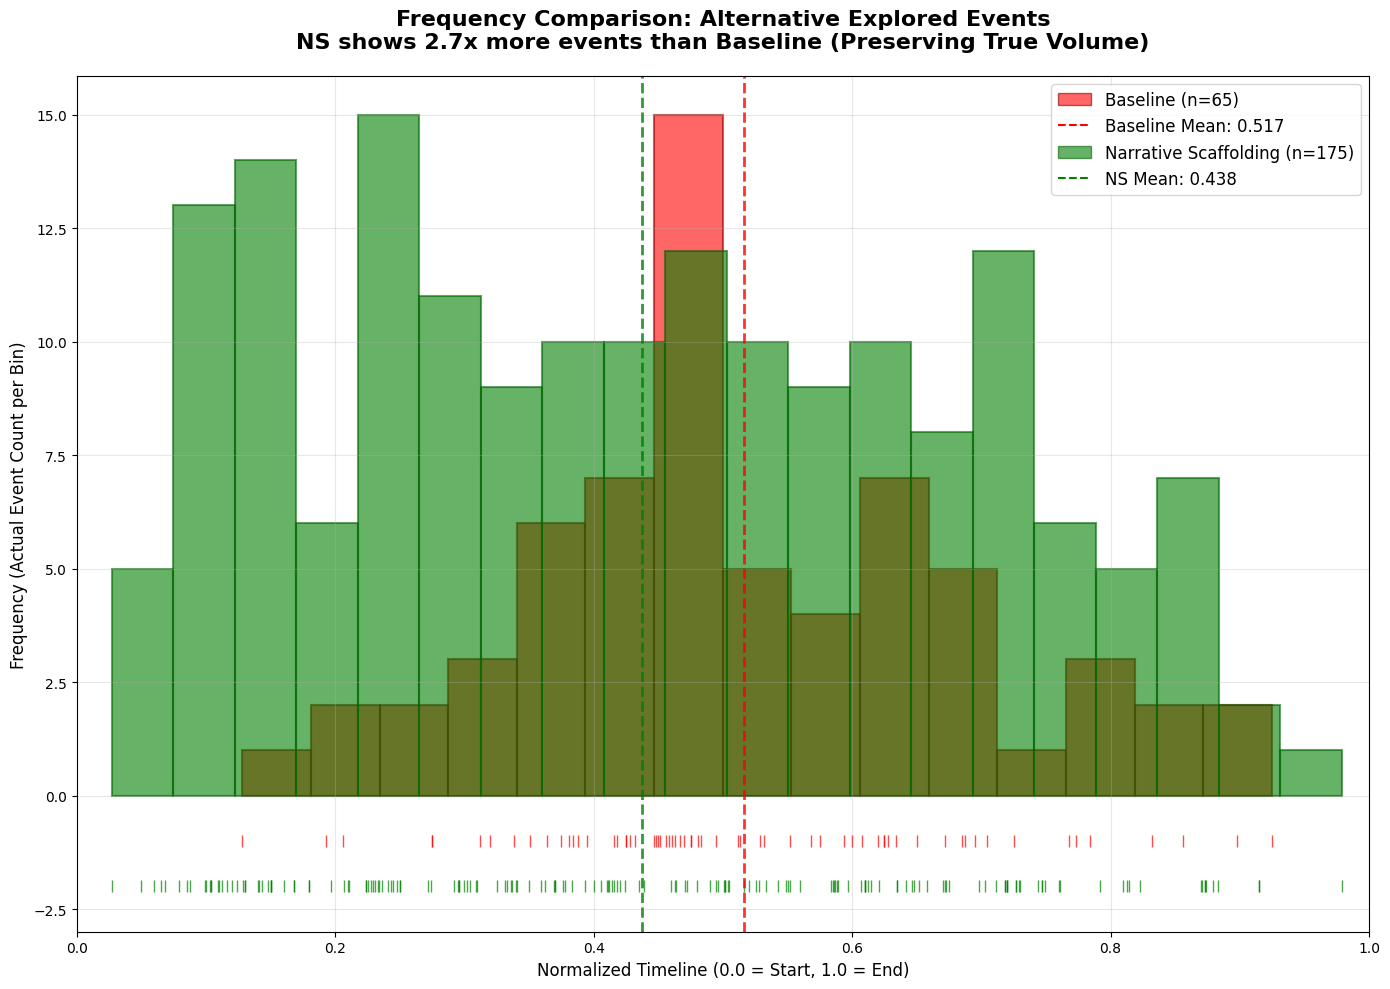

In [37]:
# Create combined frequency histogram showing true volume difference
plt.figure(figsize=(14, 10))

# Plot both conditions on same axes with frequency (not density)
if alternative_events['baseline']:
    counts_b, bins_b, patches_b = plt.hist(alternative_events['baseline'], bins=15, 
                                          alpha=0.6, color='red', edgecolor='darkred', 
                                          linewidth=1.5, label=f'Baseline (n={len(alternative_events["baseline"])})')

if alternative_events['ns']:
    counts_ns, bins_ns, patches_ns = plt.hist(alternative_events['ns'], bins=20, 
                                             alpha=0.6, color='green', edgecolor='darkgreen', 
                                             linewidth=1.5, label=f'Narrative Scaffolding (n={len(alternative_events["ns"])})')

# Add rug plots
if alternative_events['baseline']:
    plt.plot(alternative_events['baseline'], 
             np.full_like(alternative_events['baseline'], -1), 
             '|', color='red', markersize=8, alpha=0.7)

if alternative_events['ns']:
    plt.plot(alternative_events['ns'], 
             np.full_like(alternative_events['ns'], -2), 
             '|', color='green', markersize=8, alpha=0.7)

# Add mean lines
if alternative_events['baseline']:
    mean_baseline = np.mean(alternative_events['baseline'])
    plt.axvline(mean_baseline, color='red', linestyle='--', linewidth=2, alpha=0.8)

if alternative_events['ns']:
    mean_ns = np.mean(alternative_events['ns'])
    plt.axvline(mean_ns, color='green', linestyle='--', linewidth=2, alpha=0.8)

# Get volume ratio for title
volume_ratio = len(alternative_events['ns']) / len(alternative_events['baseline']) if alternative_events['baseline'] else 0

plt.title(f'Frequency Comparison: Alternative Explored Events\nNS shows {volume_ratio:.1f}x more events than Baseline (Preserving True Volume)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Normalized Timeline (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Frequency (Actual Event Count per Bin)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(bottom=-3)

# Enhanced legend
legend_elements = []
if alternative_events['baseline']:
    legend_elements.extend([
        plt.Rectangle((0,0),1,1, facecolor='red', alpha=0.6, edgecolor='darkred',
                     label=f'Baseline (n={len(alternative_events["baseline"])})'),
        plt.Line2D([0], [0], color='red', linestyle='--',
                   label=f'Baseline Mean: {mean_baseline:.3f}')
    ])

if alternative_events['ns']:
    legend_elements.extend([
        plt.Rectangle((0,0),1,1, facecolor='green', alpha=0.6, edgecolor='darkgreen',
                     label=f'Narrative Scaffolding (n={len(alternative_events["ns"])})'),
        plt.Line2D([0], [0], color='green', linestyle='--',
                   label=f'NS Mean: {mean_ns:.3f}')
    ])

if legend_elements:
    plt.legend(handles=legend_elements, fontsize=12)

plt.tight_layout()
plt.show()

## Area Chart with Proportional Heights

Creating area charts where the height of each area is proportional to the actual event volume, emphasizing the magnitude difference between n=146 (NS) and n=26 (Baseline).

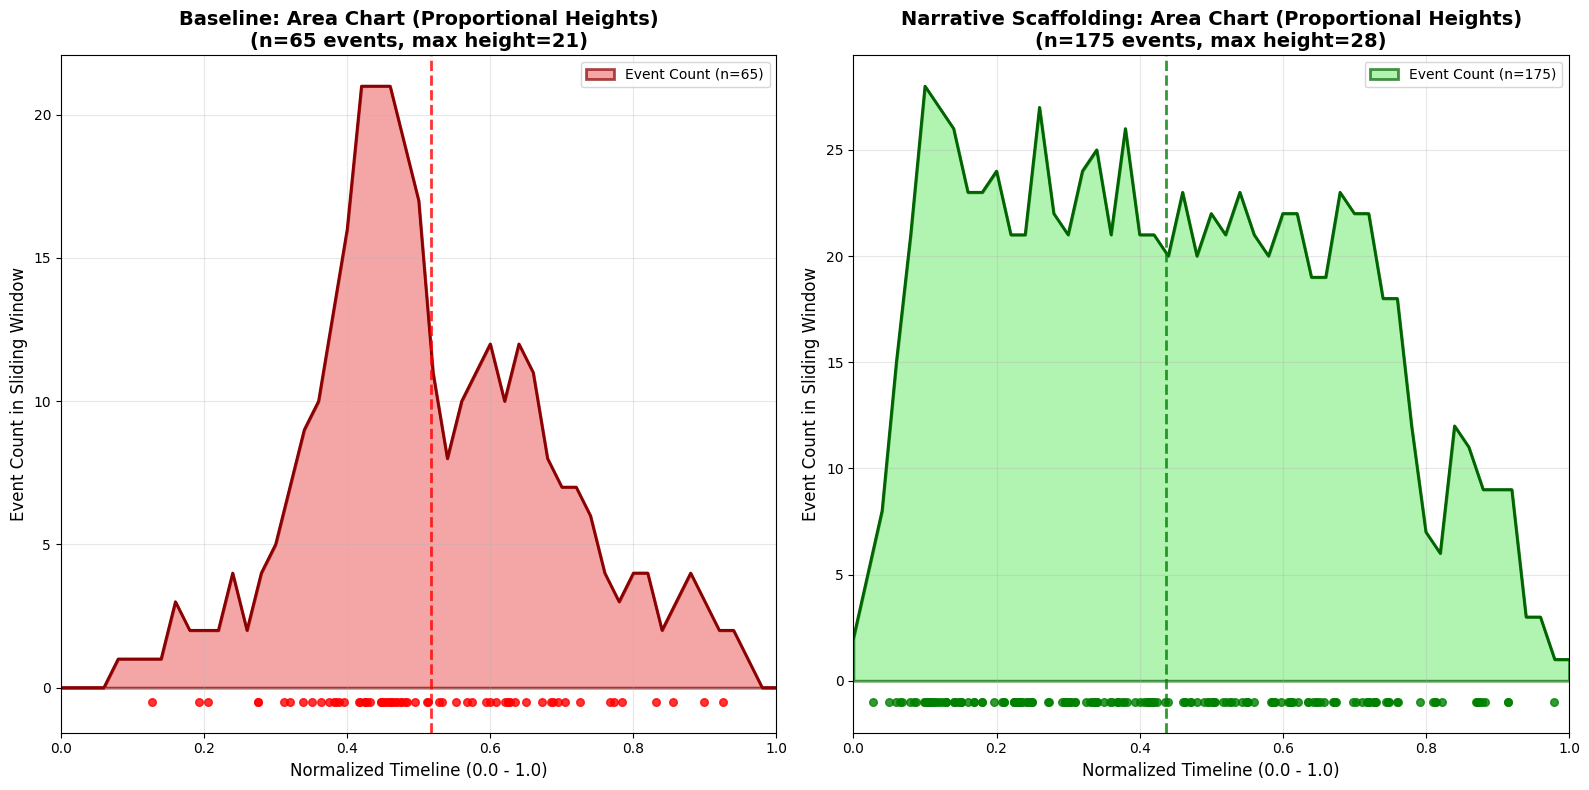


=== Area Chart Statistics ===
Maximum heights - Baseline: 21, NS: 28
Height ratio (NS/Baseline): 1.3x
Total area under curves - Baseline: 6.5, NS: 17.8
Area ratio (NS/Baseline): 2.7x


In [38]:
# Create area chart with proportional heights using moving windows
from scipy.stats import gaussian_kde

def create_proportional_area_data(events, window_size=0.1, step_size=0.02):
    """
    Create area chart data where height is proportional to event count in sliding windows
    """
    timeline = np.arange(0, 1 + step_size, step_size)
    heights = []
    
    for t in timeline:
        # Count events in window [t-window_size/2, t+window_size/2]
        window_start = max(0, t - window_size/2)
        window_end = min(1, t + window_size/2)
        
        # Count events in this window
        events_in_window = sum(1 for event in events if window_start <= event <= window_end)
        heights.append(events_in_window)
    
    return timeline, np.array(heights)

# Create proportional area data
baseline_timeline, baseline_heights = create_proportional_area_data(
    alternative_events['baseline'] if alternative_events['baseline'] else []
)
ns_timeline, ns_heights = create_proportional_area_data(
    alternative_events['ns'] if alternative_events['ns'] else []
)

# Create side-by-side area charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Baseline area chart
if alternative_events['baseline']:
    ax1.fill_between(baseline_timeline, baseline_heights, alpha=0.7, color='lightcoral', 
                     edgecolor='darkred', linewidth=2, label=f'Event Count (n={len(alternative_events["baseline"])})')
    ax1.plot(baseline_timeline, baseline_heights, color='darkred', linewidth=2)
    
    # Add individual event markers
    ax1.scatter(alternative_events['baseline'], 
                np.full_like(alternative_events['baseline'], -0.5), 
                color='red', s=30, alpha=0.8, zorder=5)
    
    # Statistics
    max_height_b = max(baseline_heights) if len(baseline_heights) > 0 else 0
    mean_baseline = np.mean(alternative_events['baseline'])
    ax1.axvline(mean_baseline, color='red', linestyle='--', linewidth=2, alpha=0.8)
    
    ax1.set_title(f'Baseline: Area Chart (Proportional Heights)\n(n={len(alternative_events["baseline"])} events, max height={max_height_b:.0f})', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Event Count in Sliding Window', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.legend()
else:
    ax1.text(0.5, 0.5, 'No alternative_explored\nevents in baseline', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Baseline: No Events', fontsize=14, fontweight='bold')

# NS area chart
if alternative_events['ns']:
    ax2.fill_between(ns_timeline, ns_heights, alpha=0.7, color='lightgreen', 
                     edgecolor='darkgreen', linewidth=2, label=f'Event Count (n={len(alternative_events["ns"])})')
    ax2.plot(ns_timeline, ns_heights, color='darkgreen', linewidth=2)
    
    # Add individual event markers
    ax2.scatter(alternative_events['ns'], 
                np.full_like(alternative_events['ns'], -1), 
                color='green', s=30, alpha=0.8, zorder=5)
    
    # Statistics
    max_height_ns = max(ns_heights) if len(ns_heights) > 0 else 0
    mean_ns = np.mean(alternative_events['ns'])
    ax2.axvline(mean_ns, color='green', linestyle='--', linewidth=2, alpha=0.8)
    
    ax2.set_title(f'Narrative Scaffolding: Area Chart (Proportional Heights)\n(n={len(alternative_events["ns"])} events, max height={max_height_ns:.0f})', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Event Count in Sliding Window', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'No alternative_explored\nevents in NS', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Narrative Scaffolding: No Events', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print area chart statistics
print("\n=== Area Chart Statistics ===")
if alternative_events['baseline'] and alternative_events['ns']:
    baseline_max = max(baseline_heights) if len(baseline_heights) > 0 else 0
    ns_max = max(ns_heights) if len(ns_heights) > 0 else 0
    
    print(f"Maximum heights - Baseline: {baseline_max:.0f}, NS: {ns_max:.0f}")
    if baseline_max > 0:
        height_ratio = ns_max / baseline_max
        print(f"Height ratio (NS/Baseline): {height_ratio:.1f}x")
    
    # Total area under curves (represents total events)
    baseline_area = np.trapz(baseline_heights, baseline_timeline)
    ns_area = np.trapz(ns_heights, ns_timeline)
    print(f"Total area under curves - Baseline: {baseline_area:.1f}, NS: {ns_area:.1f}")
    
    area_ratio = ns_area / baseline_area if baseline_area > 0 else 0
    print(f"Area ratio (NS/Baseline): {area_ratio:.1f}x")

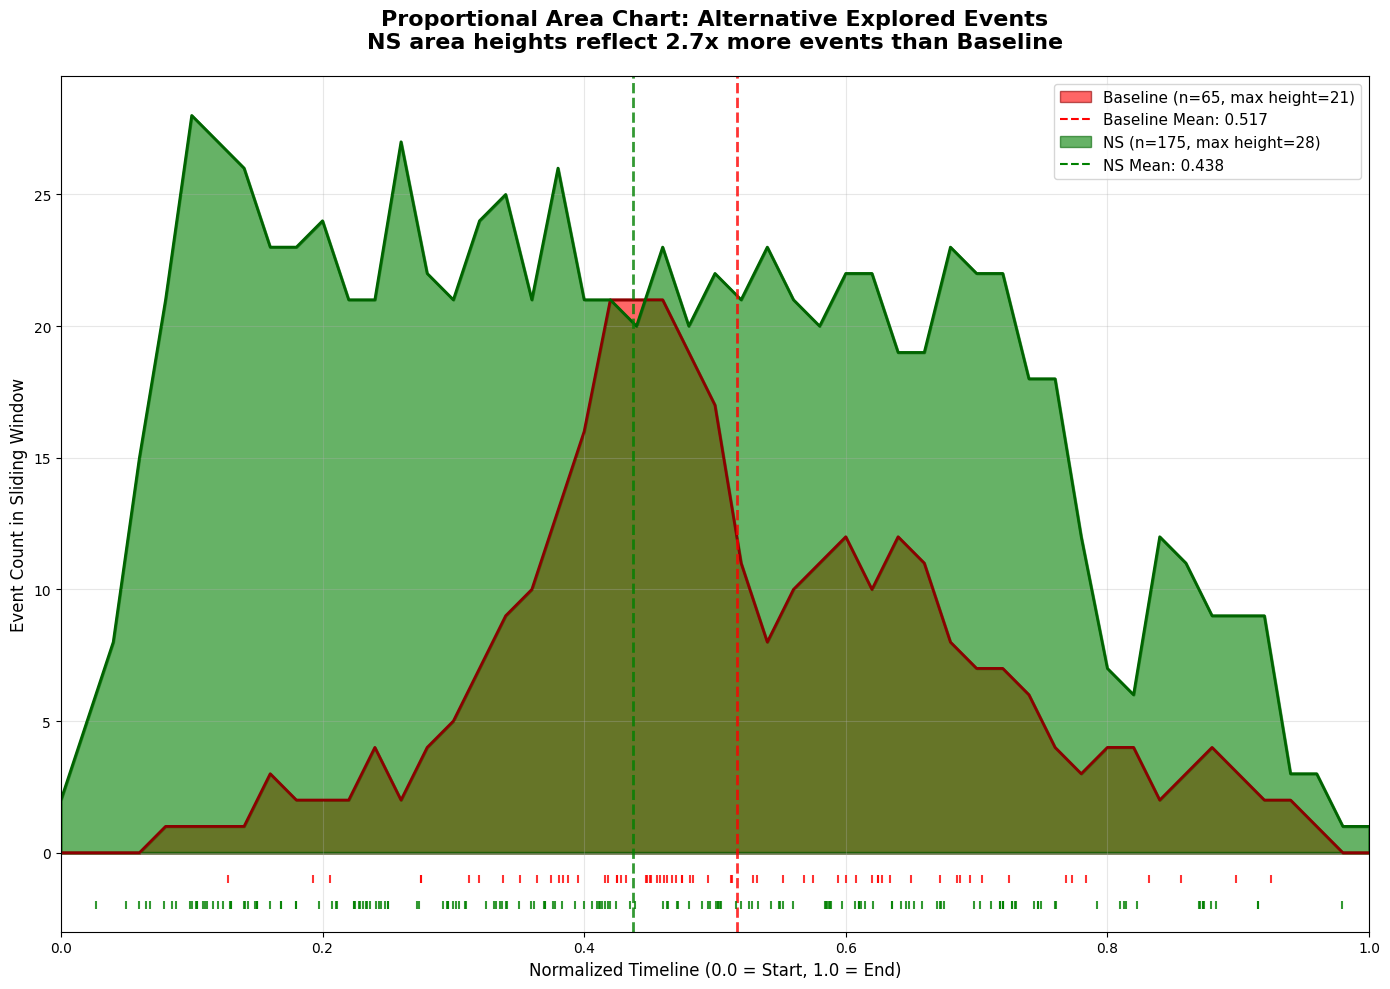

In [39]:
# Create combined area chart with proportional heights
plt.figure(figsize=(14, 10))

# Plot both area charts on same axes for direct comparison
if alternative_events['baseline']:
    plt.fill_between(baseline_timeline, baseline_heights, alpha=0.6, color='red', 
                     edgecolor='darkred', linewidth=2, label=f'Baseline (n={len(alternative_events["baseline"])})')
    plt.plot(baseline_timeline, baseline_heights, color='darkred', linewidth=2)

if alternative_events['ns']:
    plt.fill_between(ns_timeline, ns_heights, alpha=0.6, color='green', 
                     edgecolor='darkgreen', linewidth=2, label=f'Narrative Scaffolding (n={len(alternative_events["ns"])})')
    plt.plot(ns_timeline, ns_heights, color='darkgreen', linewidth=2)

# Add individual event markers
if alternative_events['baseline']:
    plt.scatter(alternative_events['baseline'], 
                np.full_like(alternative_events['baseline'], -1), 
                color='red', s=40, alpha=0.8, zorder=5, marker='|')

if alternative_events['ns']:
    plt.scatter(alternative_events['ns'], 
                np.full_like(alternative_events['ns'], -2), 
                color='green', s=40, alpha=0.8, zorder=5, marker='|')

# Add mean lines
if alternative_events['baseline']:
    baseline_mean = np.mean(alternative_events['baseline'])
    plt.axvline(baseline_mean, color='red', linestyle='--', linewidth=2, alpha=0.8)

if alternative_events['ns']:
    ns_mean = np.mean(alternative_events['ns'])
    plt.axvline(ns_mean, color='green', linestyle='--', linewidth=2, alpha=0.8)

# Calculate volume ratio for title
volume_ratio = len(alternative_events['ns']) / len(alternative_events['baseline']) if alternative_events['baseline'] else 0

plt.title(f'Proportional Area Chart: Alternative Explored Events\nNS area heights reflect {volume_ratio:.1f}x more events than Baseline', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Normalized Timeline (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Event Count in Sliding Window', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(bottom=-3)

# Enhanced legend with statistics
legend_elements = []
if alternative_events['baseline']:
    baseline_max = max(baseline_heights) if len(baseline_heights) > 0 else 0
    legend_elements.extend([
        plt.Rectangle((0,0),1,1, facecolor='red', alpha=0.6, edgecolor='darkred',
                     label=f'Baseline (n={len(alternative_events["baseline"])}, max height={baseline_max:.0f})'),
        plt.Line2D([0], [0], color='red', linestyle='--',
                   label=f'Baseline Mean: {baseline_mean:.3f}')
    ])

if alternative_events['ns']:
    ns_max = max(ns_heights) if len(ns_heights) > 0 else 0
    legend_elements.extend([
        plt.Rectangle((0,0),1,1, facecolor='green', alpha=0.6, edgecolor='darkgreen',
                     label=f'NS (n={len(alternative_events["ns"])}, max height={ns_max:.0f})'),
        plt.Line2D([0], [0], color='green', linestyle='--',
                   label=f'NS Mean: {ns_mean:.3f}')
    ])

if legend_elements:
    plt.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.show()

In [40]:
# Calculate average participant profiles for each condition
def calculate_average_participant_distribution():
    """
    Calculate the distribution pattern for an average participant in each condition
    """
    
    # Collect individual participant event counts and patterns
    baseline_participants = {}
    ns_participants = {}
    
    event_folder = 'participant_events'
    
    # Process baseline files - get events per participant
    baseline_files = glob.glob(f'{event_folder}/*_baseline.csv')
    for file_path in baseline_files:
        try:
            participant_id = os.path.basename(file_path).replace('_baseline.csv', '')
            events_df = pd.read_csv(file_path)
            alternative_events = events_df[events_df['event_type'] == 'alternative_explored']
            
            if not alternative_events.empty:
                timestamps = alternative_events['timestamp_normalized'].tolist()
                baseline_participants[participant_id] = timestamps
            else:
                baseline_participants[participant_id] = []
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    # Process NS files - get events per participant
    ns_files = glob.glob(f'{event_folder}/*_ns.csv')
    for file_path in ns_files:
        try:
            participant_id = os.path.basename(file_path).replace('_ns.csv', '')
            events_df = pd.read_csv(file_path)
            alternative_events = events_df[events_df['event_type'] == 'alternative_explored']
            
            if not alternative_events.empty:
                timestamps = alternative_events['timestamp_normalized'].tolist()
                ns_participants[participant_id] = timestamps
            else:
                ns_participants[participant_id] = []
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    return baseline_participants, ns_participants

# Get individual participant data
baseline_participants, ns_participants = calculate_average_participant_distribution()

# Calculate statistics per participant
baseline_counts = [len(events) for events in baseline_participants.values()]
ns_counts = [len(events) for events in ns_participants.values()]

print("=== Per-Participant Statistics ===")
print(f"Baseline participants: {len(baseline_participants)}")
print(f"NS participants: {len(ns_participants)}")
print(f"Baseline events per participant: mean={np.mean(baseline_counts):.2f}, std={np.std(baseline_counts):.2f}")
print(f"NS events per participant: mean={np.mean(ns_counts):.2f}, std={np.std(ns_counts):.2f}")
print(f"Individual participant range - Baseline: {min(baseline_counts)}-{max(baseline_counts)}")
print(f"Individual participant range - NS: {min(ns_counts)}-{max(ns_counts)}")

# Calculate average participant event count
avg_baseline_events = int(round(np.mean(baseline_counts)))
avg_ns_events = int(round(np.mean(ns_counts)))

print(f"\nAverage participant profile:")
print(f"Baseline: ~{avg_baseline_events} alternative_explored events per participant")
print(f"NS: ~{avg_ns_events} alternative_explored events per participant")
print(f"Ratio: NS participants explore {avg_ns_events/avg_baseline_events:.1f}x more alternatives on average")

=== Per-Participant Statistics ===
Baseline participants: 20
NS participants: 20
Baseline events per participant: mean=3.25, std=1.58
NS events per participant: mean=8.75, std=3.03
Individual participant range - Baseline: 1-7
Individual participant range - NS: 6-18

Average participant profile:
Baseline: ~3 alternative_explored events per participant
NS: ~9 alternative_explored events per participant
Ratio: NS participants explore 3.0x more alternatives on average
